# Trabalho 1 — Aquisição de Dados

###Equipe:
*   Guilherme da Silva Pereira
*   Luiggy Augusto Lima Alves
*   Mariana Ramos André Simões
*   Vithor Junior da Encarnação Vitório

###Tema:
Relações entre as oscilações hidrológicas dos rios e a dinâmica de preços de bens de consumo na região norte.





In [1]:
import pandas as pd
import numpy as np
import requests
from pathlib import Path
from datetime import datetime
import os
import re
import glob
import unicodedata
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from urllib.robotparser import RobotFileParser
import io
import time
import zipfile
from dotenv import load_dotenv

load_dotenv()

%matplotlib inline
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)

#import sidrapy as sdp

HEADERS = {"User-Agent": "UFAM-CienciaDeDados-TrabalhoPratico-AquisicaoDeDados (uso academico)"}

RAW = Path("Dados_precos") / "Dados Brutos"
RAW.mkdir(parents=True, exist_ok=True)

TRATADOS = Path("Dados_precos") / "Dados Tratados"
TRATADOS.mkdir(parents=True, exist_ok=True)

print("Data/hora da coleta:", datetime.now().isoformat(timespec="seconds"))


Data/hora da coleta: 2026-09-13T19:52:03


In [2]:
def registrar_proveniencia(nome_arquivo, fonte_url, descricao):
    """Anexa uma linha ao log de proveniência: o que foi coletado, de onde e quando."""
    linha = f"{datetime.now().isoformat(timespec='seconds')}\t{nome_arquivo}\t{fonte_url}\t{descricao}\n"
    with open(RAW / "_proveniencia.tsv", "a", encoding="utf-8") as f:
        f.write(linha)
    print("Proveniência registrada:", nome_arquivo)

# Cabeçalho do log (só na primeira vez)
log = RAW / "_proveniencia.tsv"
if not log.exists():
    log.write_text("coletado_em\tarquivo\tfonte_url\tdescricao\n", encoding="utf-8")
print("Log de proveniência:", log)

Log de proveniência: Dados_precos\Dados Brutos\_proveniencia.tsv


# Fonte 2: IBGE — Sistema IBGE de Recuperação Automática (SIDRA), Índice de Preços ao Consumidor Amplo (IPCA)

## Titulo especifico da tabela:
Variação mensal, acumulada no ano, acumulada em 12 meses e peso mensal, para o índice geral, grupos, subgrupos, itens e subitens de produtos e serviços (a partir de janeiro/2020)

## Método de coleta: (API)

##Observação importante:


In [3]:

#url_desc = "https://servicodados.ibge.gov.br/api/v3/agregados/7060/metadados"
#resp = requests.get(url_desc)
#meta = resp.json()

# A estrutura classificacoes[] contém cada classificação (ex: "Geral, grupo, subgrupo, item e subitem")
#for classificacao in meta["classificacoes"]:
#    if classificacao["id"] == 315:
#        for categoria in classificacao["categorias"]:
#            print(categoria["id"], "-", categoria["nome"])

#7169 - Indice Geral
#7172 - 1101.Cereais, leguminosas e oleaginosas
#7184 - 1102.Farinhas, féculas e massas
#7200 - 1103.Tubérculos, raízes e legumes
#7219 - 1104.Açúcares e derivados
#7241 - 1105.Hortaliças e verduras
#7283 - 1107.Carnes
#7303 - 1108.Pescados
#7656 - 5104.Combustíveis (veículos)

In [4]:

url_IPCA_1 = "https://apisidra.ibge.gov.br/values/t/7060/n6/1200401,2704302,1600303,1302603,2927408,2304400,5300108,3205309,5208707,2111300,5103403,5002704/v/63/p/all/c315/7169,7172,7184,7200,7219,7241,7283,7303,7656"
url_IPCA_2 = "https://apisidra.ibge.gov.br/values/t/7060/n6/3106200,1501402,2507507,4106902,2611606,2211001,3304557,2408102,4314902,1100205,1400100,4205407,3550308,2800308,1721000/v/63/p/all/c315/7169,7172,7184,7200,7219,7241,7283,7303,7656"

SIMBOLOS_AUSENTES = {"..."}

resp1 = requests.get(url_IPCA_1, headers=HEADERS, timeout=30)
resp1.raise_for_status()
ipcaMetade1 = resp1.json()

resp2 = requests.get(url_IPCA_2, headers=HEADERS, timeout=30)
resp2.raise_for_status()
ipcaMetade2 = resp2.json()
ipca = ipcaMetade1 + ipcaMetade2

# Salva o BRUTO antes de transformar
(RAW / "sidra_ipca20_26_metade1.json").write_text(resp1.text, encoding="utf-8")
registrar_proveniencia("sidra_ipca20_26_metade1.json", url_IPCA_1, "VarMensalItens - Sidra IPCA20_26 - Metade_1")

(RAW / "sidra_ipca20_26_metade2.json").write_text(resp2.text, encoding="utf-8")
registrar_proveniencia("sidra_ipca20_26_metade2.json", url_IPCA_2, "VarMensalItens - Sidra IPCA20_26 - Metade_2")



Proveniência registrada: sidra_ipca20_26_metade1.json
Proveniência registrada: sidra_ipca20_26_metade2.json


##Limpeza de valores:
   - coluna "Valor" com string "..." como valor valido tem que ser igualado a um valor nulo para não atrapalhar tabelas e graficos

In [5]:
df_ipca = pd.json_normalize(ipca)
colunas = ["NN", "MN", "V", "D1C", "D1N","D3N", "D4N"]

df_ipca = df_ipca[colunas].rename(columns={
    "NN": "NivelTerritorial",
    "MN": "UnidadeMedida",
     "V": "Valor",
    "D1C": "CódigoMunicipio",
    "D1N": "Municipio",
    "D3N": "Mes",
    "D4N": "Item"
})

#Anotar essa parte no relatorio
df_ipca["Valor"] = df_ipca["Valor"].replace(list(SIMBOLOS_AUSENTES), np.nan)
df_ipca["Valor"] = pd.to_numeric(df_ipca["Valor"], errors="coerce")


# Fonte 4: ANTAQ (Agência Nacional de Transportes Aquaviários) — Painel Estatístico Aquaviário / Sistema de Desempenho Portuário (SDP)

## Titulo especifico da tabela: Estatístico Aquaviário


## Método de coleta: Download manual

In [6]:

#Verificação de permissão de raspagem da página

url = "https://estatistica.antaq.gov.br/ea/sense/download.html"
rp = RobotFileParser()
rp.set_url("https://estatistica.antaq.gov.br/robots.txt")
rp.read()

alvo = "https://estatistica.antaq.gov.br/ea/sense/download.html"
ua = "UFAM-CienciaDeDados-AulaPratica"
print("Posso raspar esta página?", rp.can_fetch(ua, alvo))

#resp = requests.get(url, headers=HEADERS, timeout=30)
#resp.raise_for_status()

# Código comentado gera o erro 403 Client Error: Forbidden for url: https://estatistica.antaq.gov.br/ea/sense/download.html



Posso raspar esta página? True


##Para que essa parte funcione é necessario baixar o arquivo .zip pelo código a seguir.

In [7]:
#!pip install gdown -q
import gdown

url = "https://drive.google.com/file/d/1ee4QDdmMIxwMe9m9QVmGIocFEMQJP1wV/view?usp=sharing"
CAMINHO_ZIP_ANTAQ = str(RAW / "estatistico.zip")
result = gdown.download(url=url, output=CAMINHO_ZIP_ANTAQ, quiet=False)

if result is not None and os.path.exists(CAMINHO_ZIP_ANTAQ):
    registrar_proveniencia("estatistico.zip", url,"Coleta via gdown (fuzzy=True). Arquivo .zip com dados estatísticos em formato .txt."
    )
else:
    print("proveniência NÃO registrada.")

Downloading...
From (original): https://drive.google.com/uc?id=1ee4QDdmMIxwMe9m9QVmGIocFEMQJP1wV
From (redirected): https://drive.google.com/uc?id=1ee4QDdmMIxwMe9m9QVmGIocFEMQJP1wV&confirm=t&uuid=5050cb63-a67e-49e5-8b60-4f9c71ad103b
To: c:\Users\Luiggy\TP1 - CD\Dados_precos\Dados Brutos\estatistico.zip
100%|██████████| 909M/909M [00:29<00:00, 31.3MB/s] 


Proveniência registrada: estatistico.zip


##Com o .zip baixado, é preciso extrair somente os arquivos do intervalo de pesquisa (2020-2026) + os arquivos que não tem anos no nome.

In [8]:
EXTRACT_DIR = str(RAW) + os.sep
ANO_MIN, ANO_MAX = 2020, 2026

with zipfile.ZipFile(str(RAW / "estatistico.zip"), "r") as z:
    todos_nomes = z.namelist()

    nomes_filtrados = []
    for nome in todos_nomes:
        base = os.path.basename(nome)
        m = re.search(r"(20\d{2})", base)

        if m is None or (ANO_MIN <= int(m.group(1)) <= ANO_MAX):
            nomes_filtrados.append(nome)

    print(f"Total no zip: {len(todos_nomes)} | Selecionados para extrair: {len(nomes_filtrados)}")

    for nome in nomes_filtrados:
        z.extract(nome, EXTRACT_DIR)

print("Extração concluída em:", EXTRACT_DIR)


Total no zip: 181 | Selecionados para extrair: 101
Extração concluída em: Dados_precos\Dados Brutos\


##Nesta célula é feita a localização dos arquivos sobre atracação,carga e mercadorias e aloca eles em variaveis para facilitar manipulações futuras

In [9]:
todos_atrac = glob.glob(f"{EXTRACT_DIR}/**/*Atracacao.txt", recursive=True)
todos_carga = glob.glob(f"{EXTRACT_DIR}/**/*Carga.txt", recursive=True)

# mantém o padrão "...Carga.txt" e "...Atracacao.txt" (exclui Carga_Conteinerizada, CargaAreas)
arquivos_atrac = sorted([c for c in todos_atrac if re.fullmatch(r"\d{4}Atracacao\.txt", os.path.basename(c))])
arquivos_carga = sorted([c for c in todos_carga if re.fullmatch(r"\d{4}Carga\.txt", os.path.basename(c))])
caminho_mercadoria = glob.glob(f"{EXTRACT_DIR}/**/Mercadoria.txt", recursive=True)[0]

##Aqui fazemos uma nova filtração para os arquivos, dividindo eles em: arquivos relacionados a atracação, arquivos relacionados a carga e arquivos relacionados a mercadoria dessa carga

In [10]:
#ATRACAÇÃO#

COLUNAS_ATRAC = ["IDAtracacao", "Porto Atracação", "Município", "UF", "SGUF",
                  "Data Atracação", "Ano", "Mes", "Tipo de Navegação da Atracação"]

lista_atrac_am = []
for f in arquivos_atrac:
    df_antaq = pd.read_csv(f, sep=";", encoding="utf-8-sig", decimal=",", low_memory=False)
    df_antaq["Data Atracação"] = pd.to_datetime(df_antaq["Data Atracação"], format="%d/%m/%Y %H:%M:%S", errors="coerce")
    df_am = df_antaq[df_antaq["SGUF"] == "AM"][COLUNAS_ATRAC].copy()
    df_am["arquivo_origem"] = os.path.basename(f)
    lista_atrac_am.append(df_am)

atrac_am = pd.concat(lista_atrac_am, ignore_index=True)
ids_am = set(atrac_am["IDAtracacao"])
print(f"\nTotal de atracações no AM (2020-2026): {len(atrac_am):,}")
print("Portos únicos no AM:", sorted(atrac_am["Porto Atracação"].unique()))



Total de atracações no AM (2020-2026): 71,046
Portos únicos no AM: ['ATEM Manaus', 'ATR Logística - Chibatão', 'Amazon Aço Indústria e Comércio Ltda', 'Bemar III', 'Chibatão Navegação e Comércio', 'Ciagram Portos e Navegação da Amazônia', 'Cimento Vencemos', 'Estação EAG - Bertolini', 'Ipiranga Manaus', 'Itacal- Itacoatiara Calcários Ltda', 'J A Leite Navegação', 'J. F. de Oliveira - Manaus', 'J. F. de Oliveira Humaitá', 'Manaus', 'Petróleo Sabbá - Terminal Manaus', 'Ponta Negra', 'Porto Brasilit', 'Porto Chibatão', 'Rio Amazonas Terminais e Empreendimentos', 'Ronav', 'Super Terminais Comércio e Indústria', 'TUP Carinhoso', 'TUP Ibepar', 'TUP Moss', 'TUP Ocrim', 'Terminais Fluviais do Brasil', 'Terminal Aquaviário Solimões - Coari', 'Terminal Aquaviário de Manaus', 'Terminal Distribuidora Equador Manaus', 'Terminal Graneleiro Hermasa', 'Terminal Navecunha', 'Terminal Portuário Novo Remanso']


In [11]:
#CARGA#
COLUNAS_CARGA = ["IDCarga", "IDAtracacao", "CDMercadoria", "Natureza da Carga",
                  "Sentido", "VLPesoCargaBruta", "TEU", "QTCarga"]

lista_carga_am = []
for f in arquivos_carga:
    for chunk in pd.read_csv(f, sep=";", encoding="utf-8-sig", decimal=",",
                              usecols=COLUNAS_CARGA, chunksize=200_000):
        chunk_am = chunk[chunk["IDAtracacao"].isin(ids_am)]
        if len(chunk_am) > 0:
            lista_carga_am.append(chunk_am)
    print(f"Processado: {os.path.basename(f)}")

carga_am = pd.concat(lista_carga_am, ignore_index=True)
print(f"\nTotal de linhas de carga no AM (2020-2026): {len(carga_am):,}")

Processado: 2020Carga.txt
Processado: 2021Carga.txt
Processado: 2022Carga.txt
Processado: 2023Carga.txt
Processado: 2024Carga.txt
Processado: 2025Carga.txt
Processado: 2026Carga.txt

Total de linhas de carga no AM (2020-2026): 1,376,299


In [12]:
#JUNTA ATRACAÇÃO COM MERCADORIA#

carga_am = carga_am.merge(atrac_am, on="IDAtracacao", how="left")

df_mercadoria = pd.read_csv(caminho_mercadoria, sep=";", encoding="utf-8-sig")
carga_am = carga_am.merge(
    df_mercadoria[["CDMercadoria", "Grupo de Mercadoria", "Mercadoria"]],
    on="CDMercadoria", how="left"
)

print(carga_am.shape)
carga_am.head()

(1376299, 19)


,IDCarga,IDAtracacao,CDMercadoria,Natureza da Carga,Sentido,TEU,QTCarga,VLPesoCargaBruta,Porto Atracação,Município,UF,SGUF,Data Atracação,Ano,Mes,Tipo de Navegação da Atracação,arquivo_origem,Grupo de Mercadoria,Mercadoria
0,25381887,1049139,2901,Granel Líquido e Gasoso,Embarcados,0.0,0,8646.888,Terminal Aquaviário Solimões - Coari,Coari,Amazonas,AM,2020-01-02 16:25:00,2020,jan,Interior,2020Atracacao.txt,Produtos químicos orgânicos,Hidrocarbonetos acíclicos
1,25382318,1049151,22T6,Carga Conteinerizada,Embarcados,1.0,1,3.540,Porto Chibatão,Manaus,Amazonas,AM,2019-12-30 16:15:00,2020,jan,Cabotagem,2020Atracacao.txt,Contêineres,"TANK DANGER. LIQU. 6 BAR,20'/8'6"
2,25382319,1049151,22G0,Carga Conteinerizada,Desembarcados,49.0,49,1473.074,Porto Chibatão,Manaus,Amazonas,AM,2019-12-30 16:15:00,2020,jan,Cabotagem,2020Atracacao.txt,Contêineres,GENERAL PURPOSE(20'/8'6)-DRY 20'
3,25382320,1049151,22G0,Carga Conteinerizada,Desembarcados,2.0,2,20.072,Porto Chibatão,Manaus,Amazonas,AM,2019-12-30 16:15:00,2020,jan,Cabotagem,2020Atracacao.txt,Contêineres,GENERAL PURPOSE(20'/8'6)-DRY 20'
4,25382321,1049151,22G0,Carga Conteinerizada,Desembarcados,1.0,1,3.276,Porto Chibatão,Manaus,Amazonas,AM,2019-12-30 16:15:00,2020,jan,Cabotagem,2020Atracacao.txt,Contêineres,GENERAL PURPOSE(20'/8'6)-DRY 20'


##Limpeza dos dados

In [13]:
carga_am["VLPesoCargaBruta"] = pd.to_numeric(carga_am["VLPesoCargaBruta"], errors="coerce")

n_antes = len(carga_am)
carga_am = carga_am.dropna(subset=["VLPesoCargaBruta", "Data Atracação"])
print(f"Linhas descartadas por peso ou data ausente: {n_antes - len(carga_am)} "
      f"({(n_antes - len(carga_am)) / n_antes:.2%})")

carga_am["AnoMes"] = carga_am["Data Atracação"].dt.to_period("M").astype(str)

Linhas descartadas por peso ou data ausente: 0 (0.00%)


In [14]:
agg_mensal = (
    carga_am.groupby(["AnoMes", "Natureza da Carga", "Sentido"], as_index=False)
    ["VLPesoCargaBruta"].sum()
    .rename(columns={"VLPesoCargaBruta": "ToneladasMovimentadas"})
)

print(f"Cobertura real: {agg_mensal['AnoMes'].min()} até {agg_mensal['AnoMes'].max()}")
print(f"Total de meses distintos: {carga_am['AnoMes'].nunique()} (esperado: até 84, jan/2020-dez/2026)")
agg_mensal

TRATADOS.mkdir(parents=True, exist_ok=True)

carga_am.to_csv(TRATADOS / "antaq_carga_am_detalhado_2020_2026.csv", index=False)
agg_mensal.to_csv(TRATADOS / "antaq_carga_am_mensal_2020_2026.csv", index=False)

registrar_proveniencia(
    "antaq_carga_am_mensal_2020_2026.csv",
    url,
    f"Recorte AM 2020-2026, agregado mensal por Natureza da Carga e Sentido. "
    f"{len(carga_am):,} registros de carga -> {len(agg_mensal)} linhas agregadas."
)

Cobertura real: 2018-10 até 2026-05
Total de meses distintos: 79 (esperado: até 84, jan/2020-dez/2026)
Proveniência registrada: antaq_carga_am_mensal_2020_2026.csv


In [15]:
meses_esperados = pd.period_range("2020-01", "2026-12", freq="M").astype(str)
meses_presentes = set(carga_am["AnoMes"].unique())
meses_faltando = sorted(set(meses_esperados) - meses_presentes)

print(f"Meses esperados: {len(meses_esperados)} | Meses presentes: {len(meses_presentes)}")
print(f"Meses faltando: {meses_faltando if meses_faltando else 'nenhum ✅'}")

colunas_chave = ["IDCarga", "IDAtracacao", "Data Atracação", "Porto Atracação",
                  "Município", "SGUF", "Natureza da Carga", "Sentido", "VLPesoCargaBruta"]

print("Nulos por coluna-chave:")
print(carga_am[colunas_chave].isna().sum())

print(f"\nIDCarga duplicado: {carga_am['IDCarga'].duplicated().sum()}")
print(f"Linhas totalmente duplicadas: {carga_am.duplicated().sum()}")

Meses esperados: 84 | Meses presentes: 79
Meses faltando: ['2026-06', '2026-07', '2026-08', '2026-09', '2026-10', '2026-11', '2026-12']
Nulos por coluna-chave:
IDCarga              0
IDAtracacao          0
Data Atracação       0
Porto Atracação      0
Município            0
SGUF                 0
Natureza da Carga    0
Sentido              0
VLPesoCargaBruta     0
dtype: int64

IDCarga duplicado: 0
Linhas totalmente duplicadas: 0


# Fonte 5: CONAB — Portal de Informações Agropecuárias / Programa Prohort

##Titulo especifico da tabela:

##Método de coleta: Download de séries (.txt)

In [16]:
PASTA_DADOS = os.path.join("Dados_precos", "txts conab")
PASTA_SAIDA = str(TRATADOS)  # recortes _Norte.tsv já filtrados/limpos: saída tratada (padrão igual ao da ANTAQ)
CHUNKSIZE = 200_000

UFS_NORTE = {
    "AC": "ACRE",
    "AP": "AMAPA",
    "AM": "AMAZONAS",
    "PA": "PARA",
    "RO": "RONDONIA",
    "RR": "RORAIMA",
    "TO": "TOCANTINS",
}
CODIGOS_UF_NORTE = set(UFS_NORTE.keys())
NOMES_UF_NORTE = list(UFS_NORTE.values())
NOME_REGIAO = "NORTE"

os.makedirs(PASTA_SAIDA, exist_ok=True)


## Funções auxiliares


In [17]:
def detectar_encoding(caminho, tentativas=("utf-8-sig", "latin1", "cp1252")):
    for enc in tentativas:
        try:
            with open(caminho, encoding=enc) as f:
                for _ in range(5):
                    f.readline()
            return enc
        except (UnicodeDecodeError, UnicodeError):
            continue
    return "latin1"


def limpar_chunk(chunk):
    chunk.columns = [c.strip() for c in chunk.columns]
    colunas_texto = chunk.select_dtypes(include=["object", "string"]).columns
    for col in colunas_texto:
        chunk[col] = chunk[col].astype(str).str.strip()
    return chunk


def garantir_numerico(serie):
    if pd.api.types.is_numeric_dtype(serie):
        return serie
    texto = serie.astype(str).str.strip().str.replace(",", ".", regex=False)
    return pd.to_numeric(texto, errors="coerce")


def inteiro_como_texto(serie):
    numerica = pd.to_numeric(serie, errors="coerce")
    return numerica.astype("Int64").astype(str).replace("<NA>", pd.NA)


def normalizar_texto(serie):
    serie = serie.astype(str).str.strip().str.upper()
    return serie.apply(
        lambda s: unicodedata.normalize("NFKD", s).encode("ascii", "ignore").decode("ascii")
    )


def coluna_por_regex(df, padrao, preferir_numerica=False):
    candidatas = [c for c in df.columns if re.search(padrao, c, re.IGNORECASE)]
    if not candidatas:
        return None
    if preferir_numerica:
        melhor_coluna, melhor_cobertura = None, -1.0
        for c in candidatas:
            serie = df[c] if pd.api.types.is_numeric_dtype(df[c]) else garantir_numerico(df[c])
            cobertura = serie.notna().mean() if len(serie) else 0.0
            if cobertura > melhor_cobertura:
                melhor_coluna, melhor_cobertura = c, cobertura
        if melhor_coluna is not None and melhor_cobertura > 0:
            return melhor_coluna
    return candidatas[0]


def coluna_por_prioridade(df, *padroes, excluir=r"^cod"):
    for padrao in padroes:
        candidatas = [
            c for c in df.columns
            if re.search(padrao, c, re.IGNORECASE)
            and not re.search(excluir, c, re.IGNORECASE)
        ]
        if candidatas:
            return candidatas[0]
    return None


def construir_periodo(df, col_data=None, col_ano=None, col_mes=None):
    if col_data:
        datas = pd.to_datetime(df[col_data], errors="coerce", dayfirst=True, utc=True)
        return datas.dt.tz_localize(None)
    if col_ano and col_mes:
        ano_txt = inteiro_como_texto(df[col_ano])
        mes_txt = inteiro_como_texto(df[col_mes]).str.zfill(2)
        data_txt = ano_txt + "-" + mes_txt + "-01"
        return pd.to_datetime(data_txt, format="%Y-%m-%d", errors="coerce")
    return pd.Series(pd.NaT, index=df.index)


def cabecalho(texto, nivel=4):
    display(Markdown(f"{'#' * nivel} {texto}"))


def filtrar_regiao(df):
    colunas_candidatas = [
        c for c in df.columns
        if re.search(r"uf|munic|ceasa|regiao", c, re.IGNORECASE)
    ]
    if not colunas_candidatas:
        return df.iloc[0:0]

    padrao_nomes = r"\b(?:" + "|".join(NOMES_UF_NORTE) + r")\b"

    mascara = pd.Series(False, index=df.index)
    for col in colunas_candidatas:
        eh_so_municipio = (
            re.search(r"munic|ceasa", col, re.IGNORECASE)
            and not re.search(r"uf|regiao", col, re.IGNORECASE)
        )
        if eh_so_municipio:
            continue
        serie = normalizar_texto(df[col])
        mascara |= serie.isin(CODIGOS_UF_NORTE)
        mascara |= serie.str.contains(padrao_nomes, regex=True, na=False)
        mascara |= (serie == NOME_REGIAO)

    return df[mascara]


def processar_arquivo(caminho, chunksize=CHUNKSIZE):
    nome_arquivo = os.path.basename(caminho)
    print(f"\n=== {nome_arquivo} ===")

    encoding = detectar_encoding(caminho)
    print(f"  Encoding detectado: {encoding}")

    total_linhas = 0
    colunas = None
    partes_norte = []

    try:
        leitor = pd.read_csv(
            caminho, sep=";", decimal=",", encoding=encoding,
            chunksize=chunksize, on_bad_lines="warn",
        )
        for chunk in leitor:
            chunk = limpar_chunk(chunk)
            if colunas is None:
                colunas = list(chunk.columns)
            total_linhas += len(chunk)
            chunk_norte = filtrar_regiao(chunk)
            if len(chunk_norte) > 0:
                partes_norte.append(chunk_norte)
    except Exception as e:
        print(f"  ERRO ao ler o arquivo: {e}")
        return None

    df_norte = (
        pd.concat(partes_norte, ignore_index=True)
        if partes_norte else pd.DataFrame(columns=colunas)
    )

    print(f"  Colunas: {colunas}")
    print(f"  Total de linhas no arquivo: {total_linhas}")
    print(f"  Linhas da Região Norte: {len(df_norte)}")

    return {
        "arquivo": nome_arquivo,
        "total_linhas": total_linhas,
        "colunas": colunas,
        "df_norte": df_norte,
    }


## Processando arquivos (.txt)

In [18]:
arquivos = sorted(
    glob.glob(os.path.join(PASTA_DADOS, "*.txt"))
    + glob.glob(os.path.join(PASTA_DADOS, "*.csv"))
)

if not arquivos:
    print(f"Nenhum arquivo .txt/.csv encontrado em '{PASTA_DADOS}'.")

resultados = []
for caminho in arquivos:
    r = processar_arquivo(caminho)
    if r is not None:
        resultados.append(r)
        if len(r["df_norte"]) > 0:
            nome_base = os.path.splitext(r["arquivo"])[0]
            saida = os.path.join(PASTA_SAIDA, f"{nome_base}_Norte.csv")
            r["df_norte"].to_csv(saida, index=False)
            print(f"  Salvo recorte Região Norte em: {saida}")
            registrar_proveniencia(
                os.path.basename(saida),
                caminho,
                f"CONAB/Prohort - recorte Região Norte de {r['arquivo']}",
            )


=== Preos-Mnimos.txt ===
  Encoding detectado: latin1
  Colunas: ['descricao_produto_preco_minimo', 'id_produto', 'uf', 'regionalizacao', 'ano_inicio_vigencia', 'mes_incio_vigencia', 'ano_termino_vigencia', 'mes_termino_vigencia', 'preco', 'dsc_unidade_comercializacao', 'nome_normativo', 'url']
  Total de linhas no arquivo: 9941
  Linhas da Região Norte: 2926
  Salvo recorte Região Norte em: Dados_precos\Dados Tratados\Preos-Mnimos_Norte.csv
Proveniência registrada: Preos-Mnimos_Norte.csv

=== Preos-agropecurios-Mensal-Municpio.txt ===
  Encoding detectado: latin1
  Colunas: ['produto', 'classificao_produto', 'id_produto', 'nom_municipio', 'cod_ibge', 'uf', 'regiao', 'ano', 'mes', 'dsc_nivel_comercializacao', 'valor_produto_kg']
  Total de linhas no arquivo: 21145
  Linhas da Região Norte: 3650
  Salvo recorte Região Norte em: Dados_precos\Dados Tratados\Preos-agropecurios-Mensal-Municpio_Norte.csv
Proveniência registrada: Preos-agropecurios-Mensal-Municpio_Norte.csv

=== Preos-agrope

## Dados por arquivo

In [19]:
COLUNAS_RESUMO = ["arquivo", "total_linhas", "linhas_norte", "pct_norte", "tem_cobertura_norte"]

if resultados:
    resumo_df = pd.DataFrame([
        {
            "arquivo": r["arquivo"],
            "total_linhas": r["total_linhas"],
            "linhas_norte": len(r["df_norte"]),
            "pct_norte": round(100 * len(r["df_norte"]) / r["total_linhas"], 4) if r["total_linhas"] else 0,
            "tem_cobertura_norte": len(r["df_norte"]) > 0,
        }
        for r in resultados
    ]).sort_values("linhas_norte", ascending=False).reset_index(drop=True)
else:
    resumo_df = pd.DataFrame(columns=COLUNAS_RESUMO)
    print(
        f"Nenhum arquivo processado a partir de '{PASTA_DADOS}'. "
        "Coloque os .txt do Prohort/CONAB nessa pasta antes de rodar esta seção."
    )

resumo_df

,arquivo,total_linhas,linhas_norte,pct_norte,tem_cobertura_norte
0,Prohort-Mensal.txt,1703931,19781,1.1609,True
1,Preos-agropecurios-Semanal-UF.txt,86932,16133,18.5582,True
2,Preos-agropecurios-Semanal-Municpio.txt,91896,15861,17.2597,True
3,Prohort-Dirio.txt,1083843,13794,1.2727,True
4,Preos-agropecurios-Mensal-UF.txt,20346,3793,18.6425,True
5,Preos-agropecurios-Mensal-Municpio.txt,21145,3650,17.2618,True
6,Preos-Mnimos.txt,9941,2926,29.4337,True


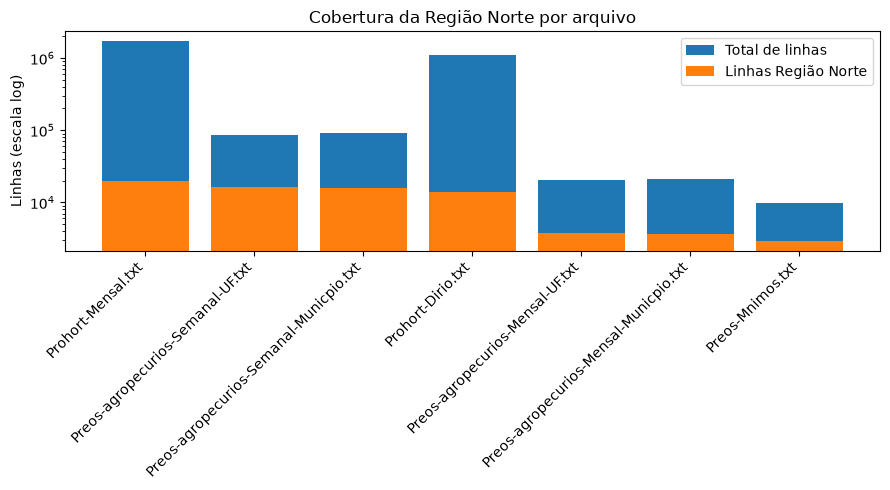

In [20]:
if resumo_df.empty:
    print("Sem dados processados da CONAB/Prohort para plotar (resumo_df está vazio).")
else:
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.bar(resumo_df["arquivo"], resumo_df["total_linhas"], label="Total de linhas")
    ax.bar(resumo_df["arquivo"], resumo_df["linhas_norte"], label="Linhas Região Norte")
    ax.set_yscale("log")
    ax.set_ylabel("Linhas (escala log)")
    ax.set_title("Cobertura da Região Norte por arquivo")
    plt.xticks(rotation=45, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Gráficos e Tabelas

### Preos-Mnimos.txt — 2926 linhas (Região Norte)

#### Visão geral dos dados

Colunas (12): ['descricao_produto_preco_minimo', 'id_produto', 'uf', 'regionalizacao', 'ano_inicio_vigencia', 'mes_incio_vigencia', 'ano_termino_vigencia', 'mes_termino_vigencia', 'preco', 'dsc_unidade_comercializacao', 'nome_normativo', 'url']


,descricao_produto_preco_minimo,id_produto,uf,regionalizacao,ano_inicio_vigencia,mes_incio_vigencia,ano_termino_vigencia,mes_termino_vigencia,preco,dsc_unidade_comercializacao,nome_normativo,url
0,AÇAÍ (FRUTO) - PRODUTO EXTRATIVO,6331,AC,AC,2014,7,2015,6,1.11,kg,"PORTARIA Nº 190, DE 9 DE",NI
1,AÇAÍ (FRUTO) - PRODUTO EXTRATIVO,6331,AC,AC,2015,7,2016,6,1.18,kg,"PORTARIA Nº 190, DE 9 DE",NI
2,AÇAÍ (FRUTO) - PRODUTO EXTRATIVO,6331,AC,AC,2016,7,2017,6,1.29,kg,"PORTARIA Nº 123, DE 5 DE JULHO",http://biblioteca.conab.gov.br/phl82/pdf/legis...
3,AÇAÍ (FRUTO) - PRODUTO EXTRATIVO,6331,AC,AC,2017,7,2017,12,1.29,kg,"PORTARIA Nº 1.577, DE 17 DE JU",http://biblioteca.conab.gov.br/phl82/pdf/legis...
4,AÇAÍ (FRUTO) - PRODUTO EXTRATIVO,6331,AC,AC,2018,1,2018,12,1.6,kg,"PORTARIA Nº 14, DE 3 DE JANEIR",http://biblioteca.conab.gov.br/phl82/pdf/legis...
5,AÇAÍ (FRUTO) - PRODUTO EXTRATIVO,6331,AC,AC,2019,1,2019,12,1.63,kg,"PORTARIA Nº 141, DE 8 DE JANEI",http://biblioteca.conab.gov.br/phl82/pdf/legis...
6,AÇAÍ (FRUTO) - PRODUTO EXTRATIVO,6331,AC,AC,2020,1,2020,12,1.41,kg,"PORTARIA Nº 313, DE 30 DE DEZE",http://biblioteca.conab.gov.br/phl82/pdf/legis...
7,AÇAÍ (FRUTO) - PRODUTO EXTRATIVO,6331,AC,AC,2021,1,2021,12,1.41,kg,PREÇOS MÍNIMOS DOS PRODUTOS DE,http://biblioteca.conab.gov.br/phl82/pdf/legis...


#### Distribuição por UF

,ocorrencias
uf,
AM,435
AP,426
AC,424
PA,424
RO,414
TO,402
RR,401


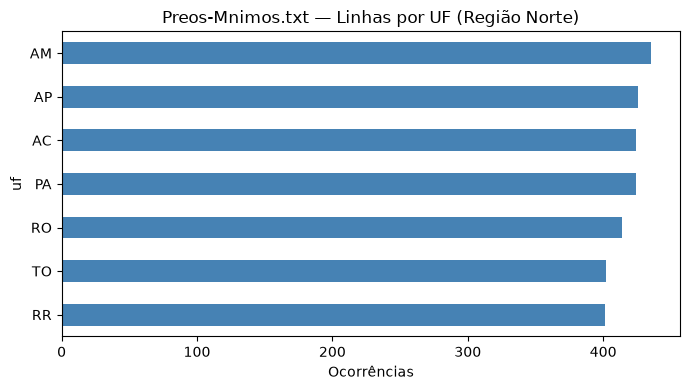

#### Produtos mais frequentes

,ocorrencias
descricao_produto_preco_minimo,
,112
ALGODÃO EM PLUMA,98
ARROZ LONGO FINO EM CASCA,98
BORRACHA NATURAL CULTIVADA,98
CAFÉ CONILON,98
CAROÇO DE ALGODÃO,98
FARINHA DE MANDIOCA,98
FEIJÃO CORES,98
FEIJÃO PRETO,98


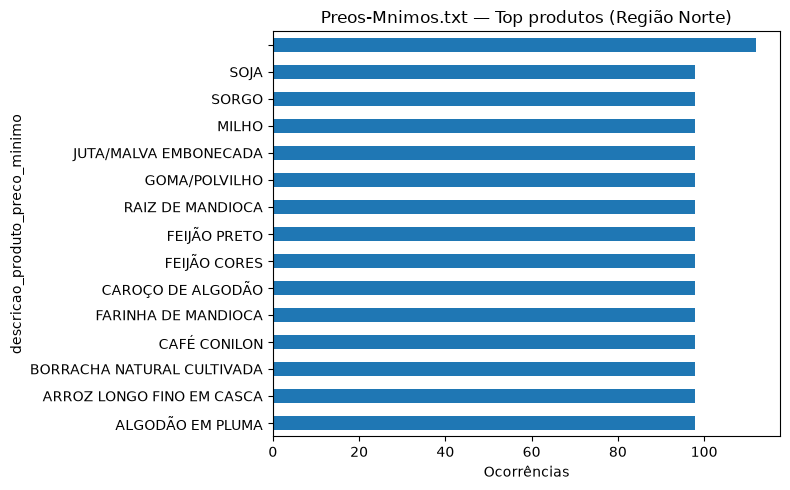

#### Evolução do valor ao longo do tempo (região)

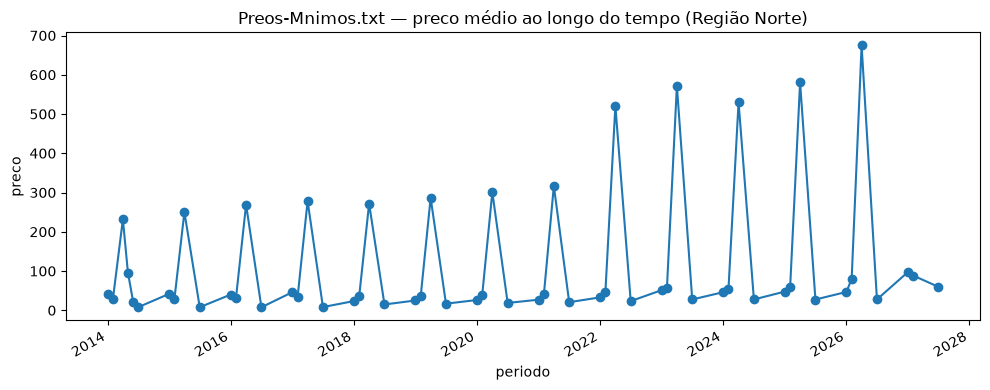

#### Evolução do valor ao longo do tempo, por UF

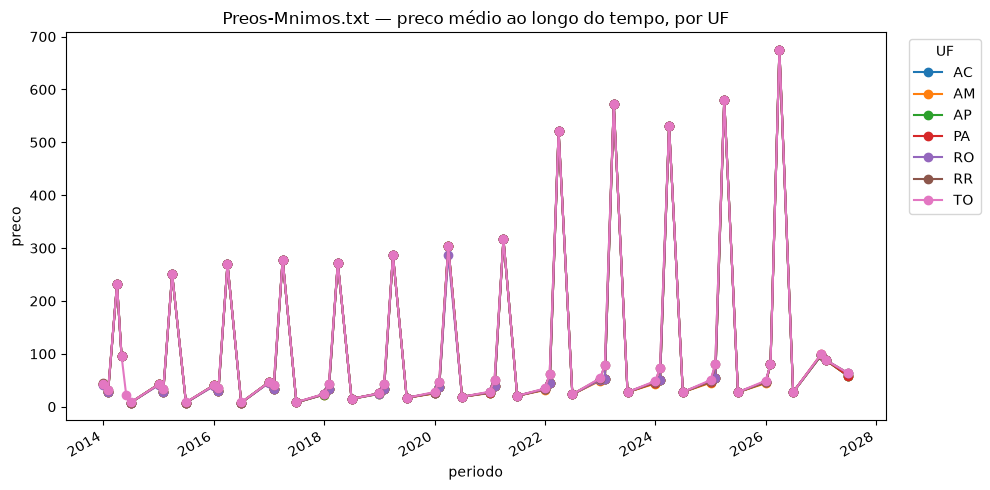

### Preos-agropecurios-Mensal-Municpio.txt — 3650 linhas (Região Norte)

#### Visão geral dos dados

Colunas (11): ['produto', 'classificao_produto', 'id_produto', 'nom_municipio', 'cod_ibge', 'uf', 'regiao', 'ano', 'mes', 'dsc_nivel_comercializacao', 'valor_produto_kg']


,produto,classificao_produto,id_produto,nom_municipio,cod_ibge,uf,regiao,ano,mes,dsc_nivel_comercializacao,valor_produto_kg
0,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2025,11,PREÇO PAGO PELO PRODUTOR,2.56
1,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2026,2,PREÇO PAGO PELO PRODUTOR,2.56
2,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2026,3,PREÇO PAGO PELO PRODUTOR,2.56
3,06-40-08,NÃO INFORMADO,14019,PEDRO AFONSO-TO,1716505,TO,NORTE,2025,11,PREÇO PAGO PELO PRODUTOR,4.84
4,06-40-08,NÃO INFORMADO,14019,PEDRO AFONSO-TO,1716505,TO,NORTE,2026,3,PREÇO PAGO PELO PRODUTOR,4.75
5,10-28-20,NÃO INFORMADO,4516,IGARAPÉ-MIRI-PA,1503309,PA,NORTE,2025,9,PREÇO PAGO PELO PRODUTOR,5.00
6,10-28-20,NÃO INFORMADO,4516,MEDICILÂNDIA-PA,1504455,PA,NORTE,2026,3,PREÇO PAGO PELO PRODUTOR,5.00
7,10-30-10,NÃO INFORMADO,12306,TUCUMÃ-PA,1508084,PA,NORTE,2025,9,PREÇO PAGO PELO PRODUTOR,4.60


#### Distribuição por UF

,ocorrencias
uf,
PA,821
TO,693
AM,615
RO,514
AC,414
AP,297
RR,296


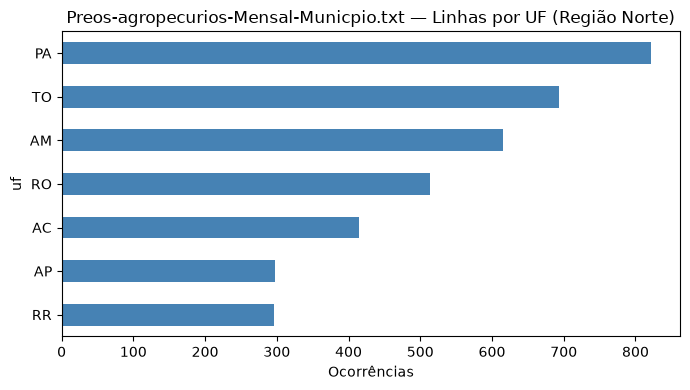

#### Produtos mais frequentes

,ocorrencias
produto,
BANANA,344
MILHO,239
CARNE BOVINA,193
LEITE DE VACA,183
FEIJAO,175
FARINHA DE MANDIOCA,172
ARROZ,136
CAFE,123
ACUCAR,91


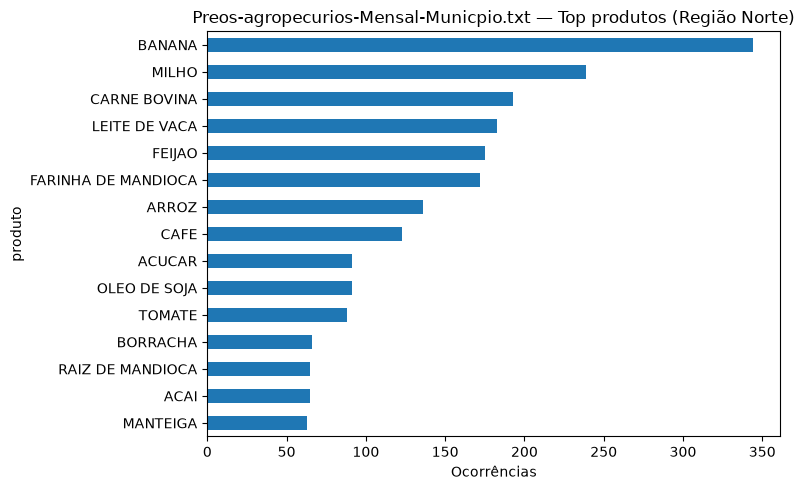

#### Municípios mais frequentes

,ocorrencias
RIO BRANCO-AC (AC),285
MANAUS-AM (AM),268
PORTO VELHO-RO (RO),265
MACAPÁ-AP (AP),260
BOA VISTA-RR (RR),260
BELÉM-PA (PA),253
PALMAS-TO (TO),245
LAGOA DA CONFUSÃO-TO (TO),209
PEDRO AFONSO-TO (TO),119
IGARAPÉ-MIRI-PA (PA),63


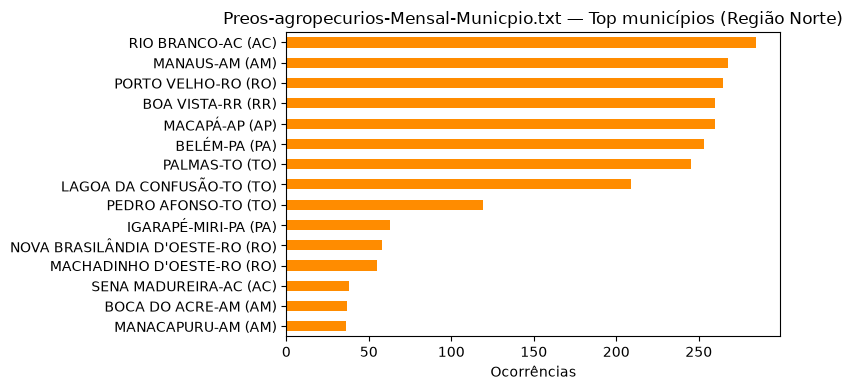

#### Evolução do valor ao longo do tempo (região)

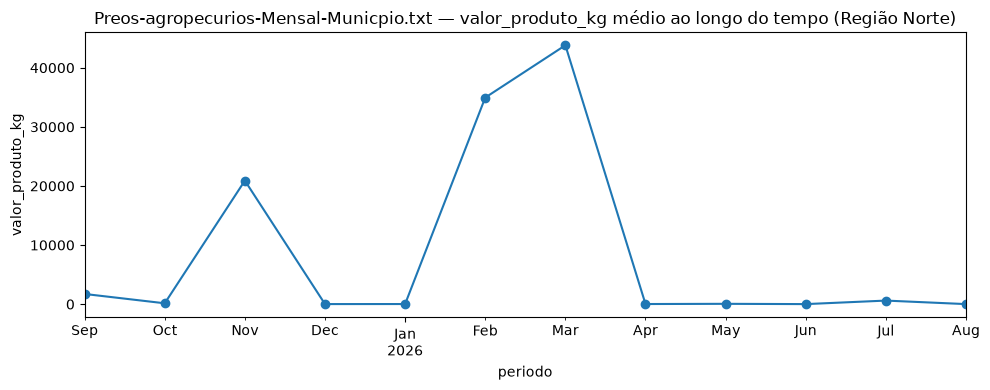

#### Evolução do valor ao longo do tempo, por UF

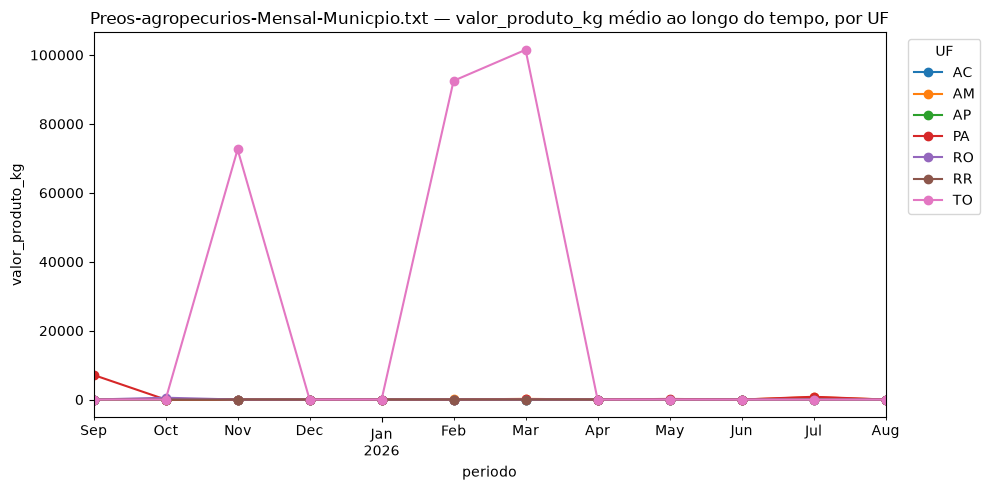

### Preos-agropecurios-Mensal-UF.txt — 3793 linhas (Região Norte)

#### Visão geral dos dados

Colunas (9): ['produto', 'classificao_produto', 'id_produto', 'uf', 'regiao', 'ano', 'mes', 'dsc_nivel_comercializacao', 'valor_produto_kg']


,produto,classificao_produto,id_produto,uf,regiao,ano,mes,dsc_nivel_comercializacao,valor_produto_kg
0,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2025,11,PREÇO PAGO PELO PRODUTOR,2.56
1,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2026,2,PREÇO PAGO PELO PRODUTOR,2.56
2,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2026,3,PREÇO PAGO PELO PRODUTOR,2.56
3,06-40-08,NÃO INFORMADO,14019,TO,NORTE,2025,11,PREÇO PAGO PELO PRODUTOR,4.84
4,06-40-08,NÃO INFORMADO,14019,TO,NORTE,2026,3,PREÇO PAGO PELO PRODUTOR,4.75
5,10-28-20,NÃO INFORMADO,4516,PA,NORTE,2025,9,PREÇO PAGO PELO PRODUTOR,5.00
6,10-28-20,NÃO INFORMADO,4516,PA,NORTE,2025,10,PREÇO PAGO PELO PRODUTOR,5.00
7,10-28-20,NÃO INFORMADO,4516,PA,NORTE,2026,3,PREÇO PAGO PELO PRODUTOR,5.00


#### Distribuição por UF

,ocorrencias
uf,
TO,726
PA,710
AM,620
RO,544
AC,483
RR,361
AP,349


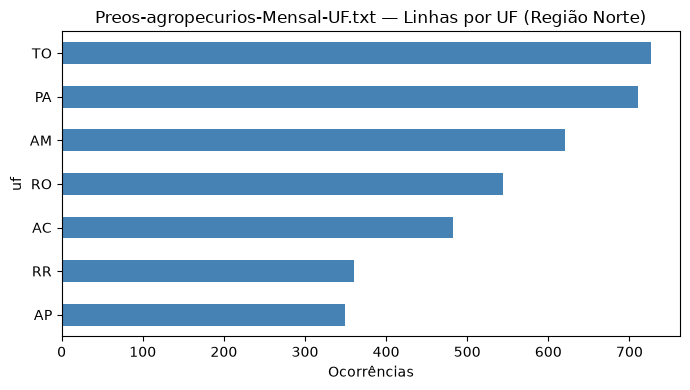

#### Produtos mais frequentes

,ocorrencias
produto,
BANANA,380
FEIJAO,213
FARINHA DE MANDIOCA,199
CARNE BOVINA,193
LEITE DE VACA,191
MILHO,156
ARROZ,136
CAFE,105
TOMATE,96


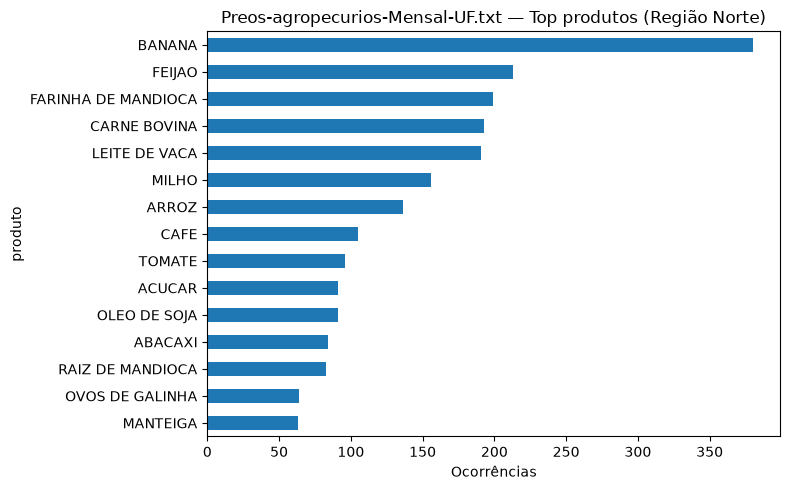

#### Evolução do valor ao longo do tempo (região)

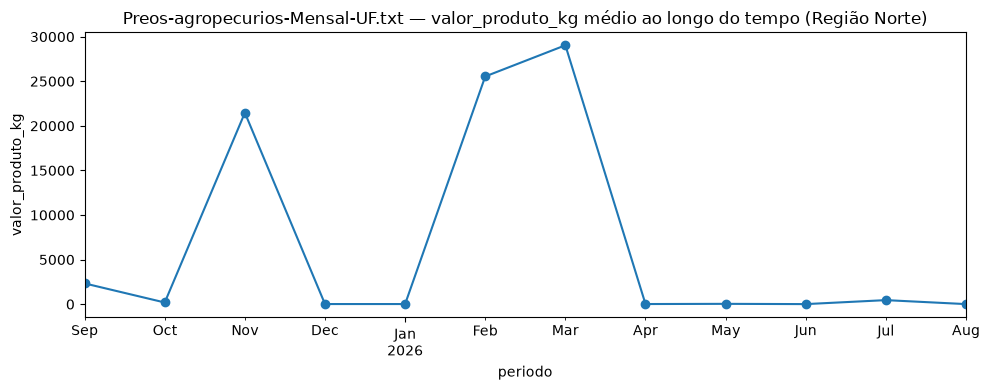

#### Evolução do valor ao longo do tempo, por UF

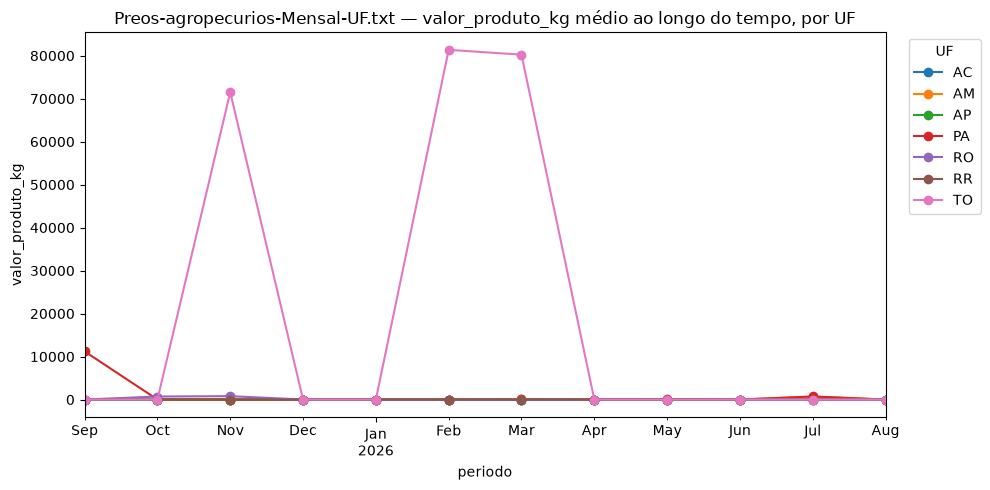

### Preos-agropecurios-Semanal-Municpio.txt — 15861 linhas (Região Norte)

#### Visão geral dos dados

Colunas (13): ['produto', 'classificao_produto', 'id_produto', 'nom_municipio', 'cod_ibge', 'uf', 'regiao', 'ano', 'mes', 'data_inicial_final_semana', 'semana', 'dsc_nivel_comercializacao', 'valor_produto_kg']


,produto,classificao_produto,id_produto,nom_municipio,cod_ibge,uf,regiao,ano,mes,data_inicial_final_semana,semana,dsc_nivel_comercializacao,valor_produto_kg
0,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2025,11,24-11-2025 - 28-11-2025,4,PREÇO PAGO PELO PROD,2.56
1,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2025,11,17-11-2025 - 21-11-2025,3,PREÇO PAGO PELO PROD,2.56
2,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2025,11,10-11-2025 - 14-11-2025,2,PREÇO PAGO PELO PROD,2.56
3,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2025,11,03-11-2025 - 07-11-2025,1,PREÇO PAGO PELO PROD,2.56
4,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2026,2,02-02-2026 - 06-02-2026,1,PREÇO PAGO PELO PROD,2.56
5,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2026,2,23-02-2026 - 27-02-2026,4,PREÇO PAGO PELO PROD,2.56
6,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2026,2,16-02-2026 - 20-02-2026,3,PREÇO PAGO PELO PROD,2.56
7,04-20-20,NÃO INFORMADO,4482,LAGOA DA CONFUSÃO-TO,1711902,TO,NORTE,2026,2,09-02-2026 - 13-02-2026,2,PREÇO PAGO PELO PROD,2.56


#### Distribuição por UF

,ocorrencias
uf,
PA,3651
TO,2901
AM,2752
RO,2276
AC,1745
RR,1299
AP,1237


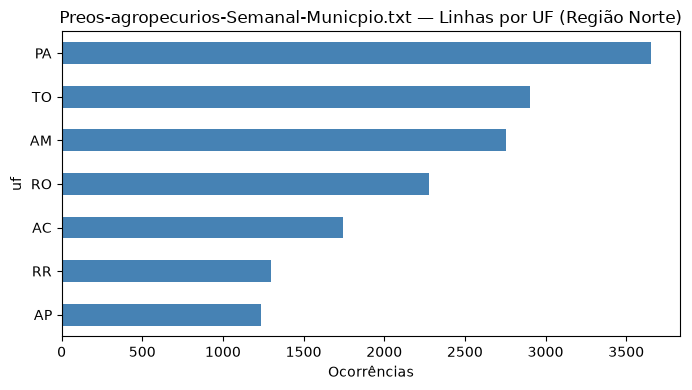

#### Produtos mais frequentes

,ocorrencias
produto,
BANANA,1482
MILHO,1024
CARNE BOVINA,837
LEITE DE VACA,796
FEIJAO,759
FARINHA DE MANDIOCA,751
ARROZ,596
CAFE,535
ACUCAR,399


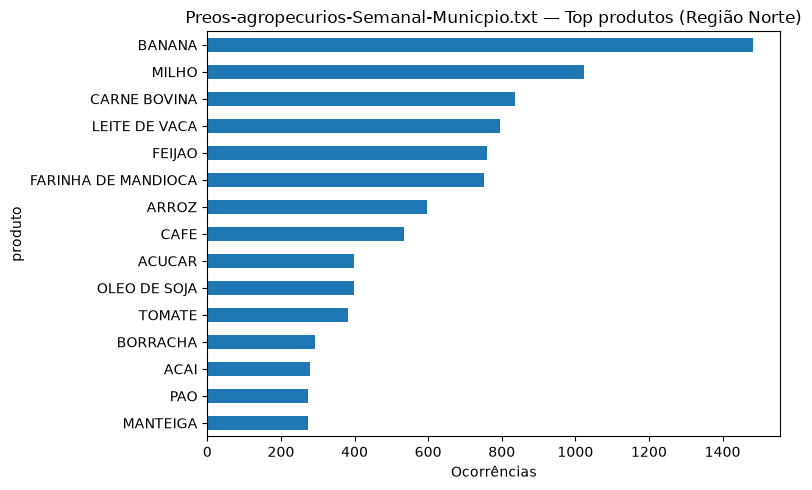

#### Municípios mais frequentes

,ocorrencias
RIO BRANCO-AC (AC),1249
MANAUS-AM (AM),1166
PORTO VELHO-RO (RO),1153
BOA VISTA-RR (RR),1137
MACAPÁ-AP (AP),1121
BELÉM-PA (PA),1107
PALMAS-TO (TO),1071
LAGOA DA CONFUSÃO-TO (TO),844
PEDRO AFONSO-TO (TO),452
IGARAPÉ-MIRI-PA (PA),298


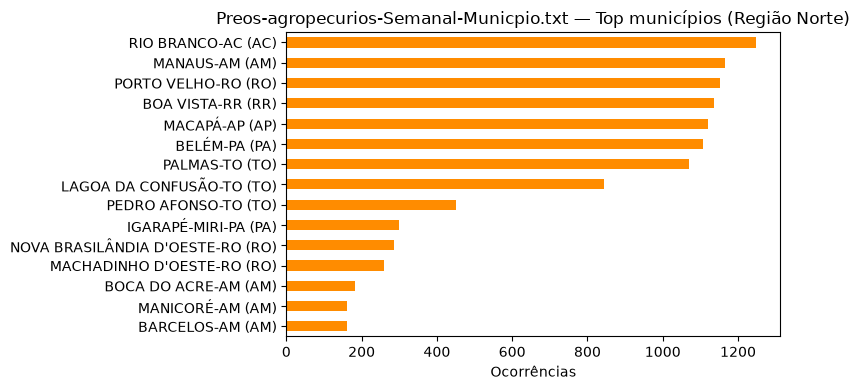

C:\Users\Luiggy\AppData\Local\Temp\ipykernel_6080\128696716.py:70: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datas = pd.to_datetime(df[col_data], errors="coerce", dayfirst=True, utc=True)


#### Evolução do valor ao longo do tempo (região)

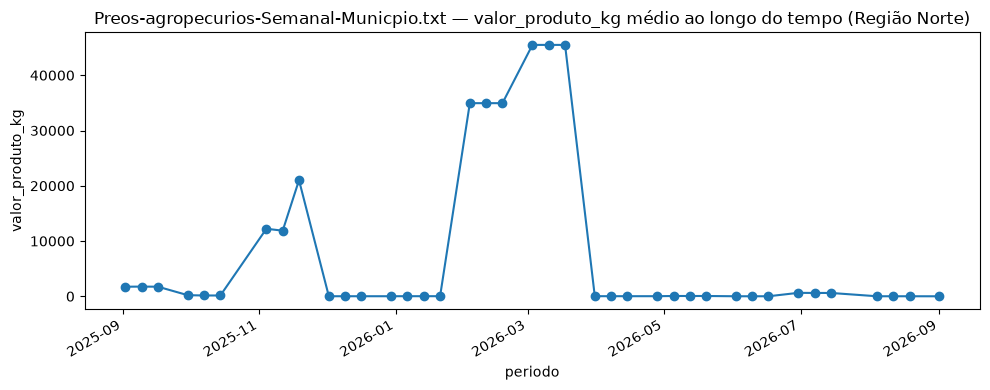

#### Evolução do valor ao longo do tempo, por UF

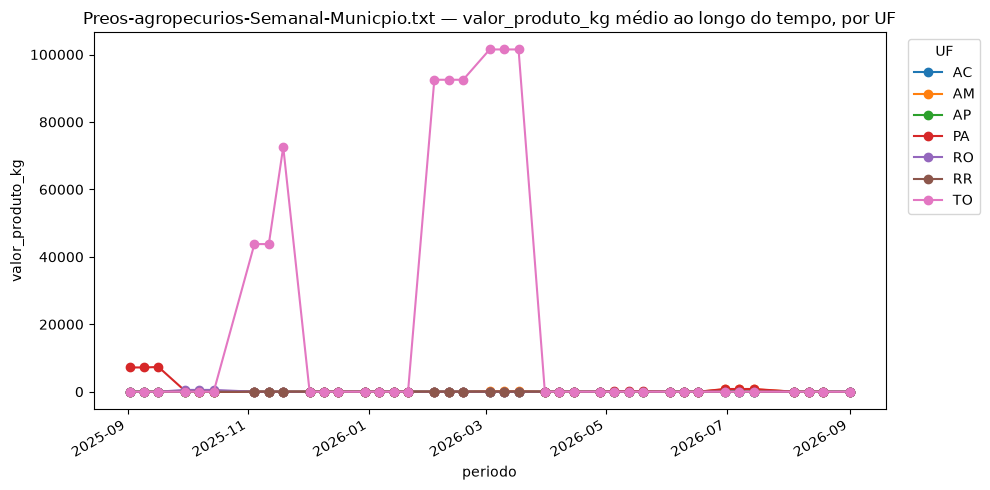

### Preos-agropecurios-Semanal-UF.txt — 16133 linhas (Região Norte)

#### Visão geral dos dados

Colunas (11): ['produto', 'classificao_produto', 'id_produto', 'uf', 'regiao', 'ano', 'mes', 'data_inicial_final_semana', 'semana', 'dsc_nivel_comercializacao', 'valor_produto_kg']


,produto,classificao_produto,id_produto,uf,regiao,ano,mes,data_inicial_final_semana,semana,dsc_nivel_comercializacao,valor_produto_kg
0,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2025,11,03-11-2025 - 07-11-2025,1,PREÇO PAGO PELO PROD,2.56
1,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2025,11,24-11-2025 - 28-11-2025,4,PREÇO PAGO PELO PROD,2.56
2,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2025,11,17-11-2025 - 21-11-2025,3,PREÇO PAGO PELO PROD,2.56
3,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2025,11,10-11-2025 - 14-11-2025,2,PREÇO PAGO PELO PROD,2.56
4,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2026,2,16-02-2026 - 20-02-2026,3,PREÇO PAGO PELO PROD,2.56
5,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2026,2,02-02-2026 - 06-02-2026,1,PREÇO PAGO PELO PROD,2.56
6,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2026,2,09-02-2026 - 13-02-2026,2,PREÇO PAGO PELO PROD,2.56
7,04-20-20,NÃO INFORMADO,4482,TO,NORTE,2026,2,23-02-2026 - 27-02-2026,4,PREÇO PAGO PELO PROD,2.56


#### Distribuição por UF

,ocorrencias
uf,
PA,3088
TO,3045
AM,2701
RO,2231
AC,2028
RR,1579
AP,1461


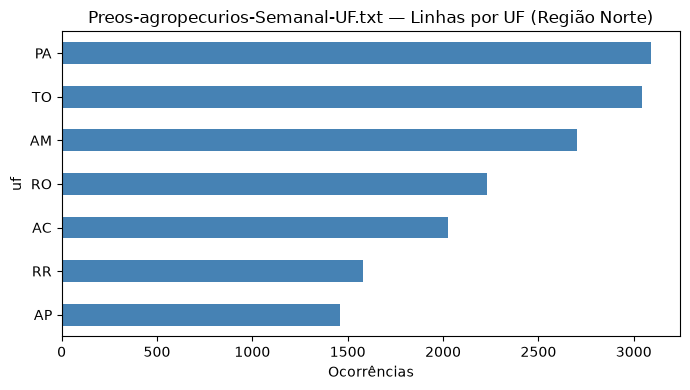

#### Produtos mais frequentes

,ocorrencias
produto,
BANANA,1634
FEIJAO,924
FARINHA DE MANDIOCA,870
CARNE BOVINA,837
LEITE DE VACA,837
MILHO,674
ARROZ,596
CAFE,451
TOMATE,417


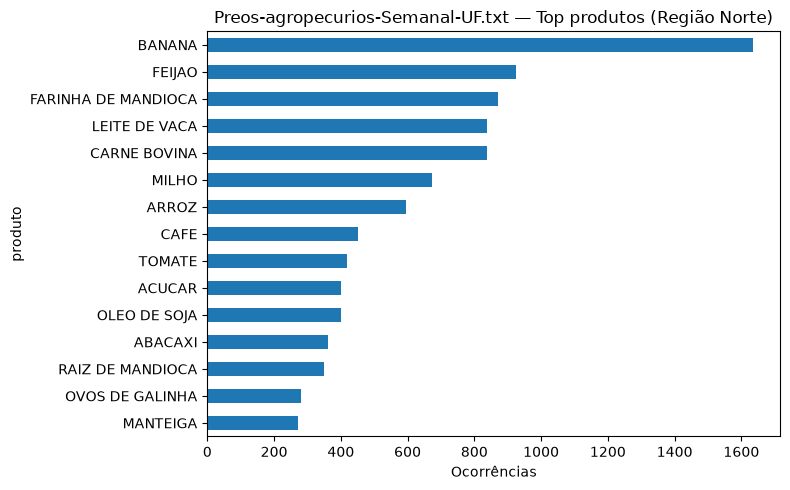

C:\Users\Luiggy\AppData\Local\Temp\ipykernel_6080\128696716.py:70: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  datas = pd.to_datetime(df[col_data], errors="coerce", dayfirst=True, utc=True)


#### Evolução do valor ao longo do tempo (região)

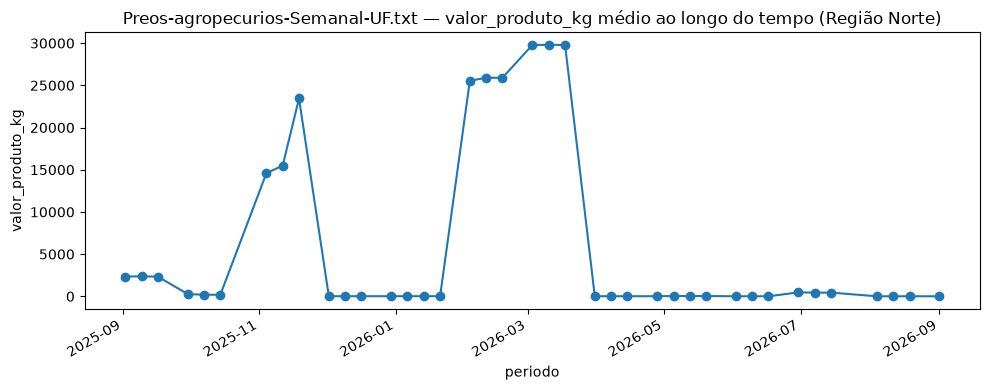

#### Evolução do valor ao longo do tempo, por UF

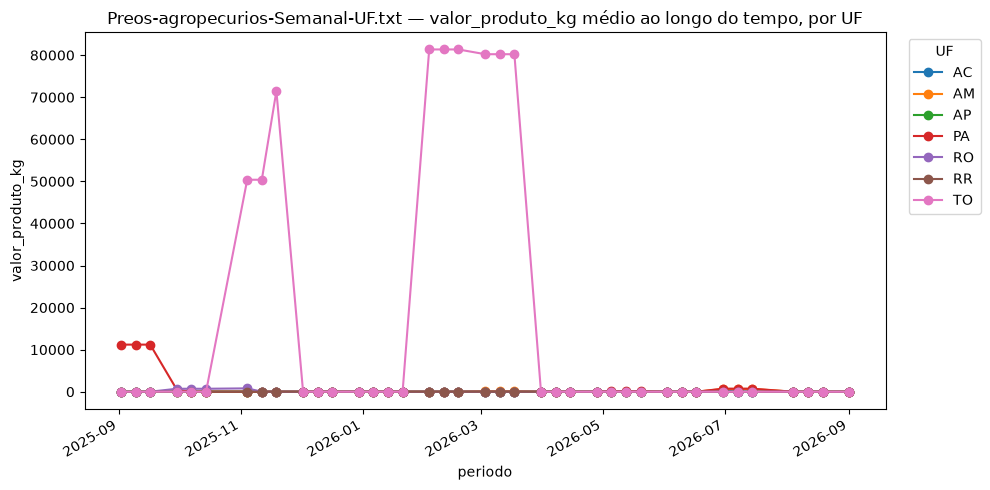

### Prohort-Dirio.txt — 13794 linhas (Região Norte)

#### Visão geral dos dados

Colunas (8): ['municipio_ceasa', 'cod_ibge_municipio', 'uf_ceasa', 'dsc_ceasa', 'dsc_produto', 'sig_unidade_medida', 'data_preco', 'preco_diario']


,municipio_ceasa,cod_ibge_municipio,uf_ceasa,dsc_ceasa,dsc_produto,sig_unidade_medida,data_preco,preco_diario
0,BELÉM-PA,1501402,PA,CEASA/PA - BELEM,ABACATE,KG,2022/07/07 00:00:00.000,6.3
1,BELÉM-PA,1501402,PA,CEASA/PA - BELEM,ABACATE,KG,2022/08/09 00:00:00.000,6.66
2,BELÉM-PA,1501402,PA,CEASA/PA - BELEM,ABACATE,KG,2022/08/23 00:00:00.000,6.62
3,BELÉM-PA,1501402,PA,CEASA/PA - BELEM,ABACATE,KG,2022/06/08 00:00:00.000,5.09
4,BELÉM-PA,1501402,PA,CEASA/PA - BELEM,ABACATE,KG,2022/06/10 00:00:00.000,5.28
5,BELÉM-PA,1501402,PA,CEASA/PA - BELEM,ABACATE,KG,2022/06/21 00:00:00.000,5.38
6,BELÉM-PA,1501402,PA,CEASA/PA - BELEM,ABACATE,KG,2022/06/03 00:00:00.000,5.31
7,BELÉM-PA,1501402,PA,CEASA/PA - BELEM,ABACATE,KG,2022/06/30 00:00:00.000,5.88


#### Distribuição por UF do Ceasa (mercado)

,ocorrencias
uf_ceasa,
PA,8825
TO,4969


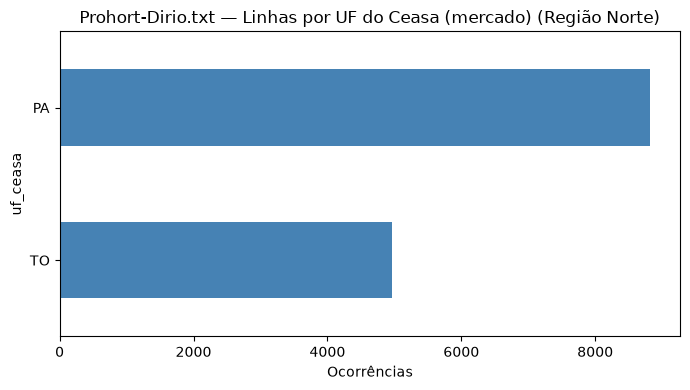

#### Produtos mais frequentes

,ocorrencias
dsc_produto,
MACA,650
PEPINO,644
MAMAO HAWAY,380
BANANA PRATA,347
LARANJA PERA,347
BANANA NANICA,346
LIMAO TAHITI,346
ALHO,345
BETERRABA,345


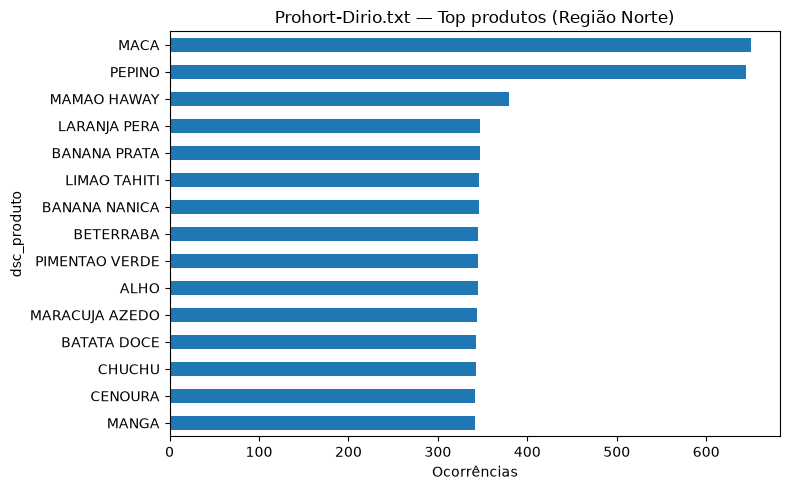

#### Municípios mais frequentes

,ocorrencias
BELÉM-PA (PA),8825
PALMAS-TO (TO),4969


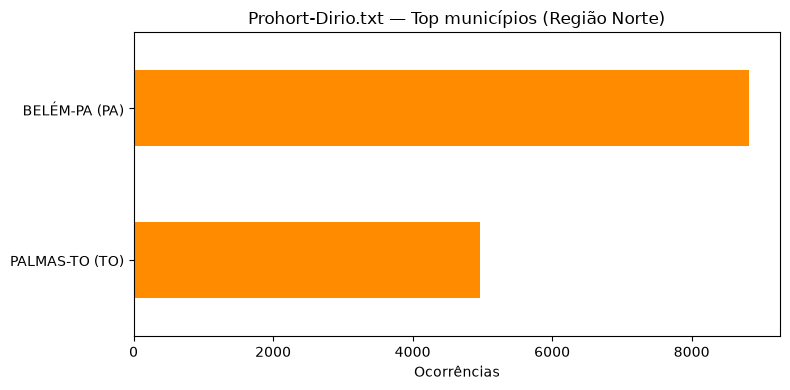

#### Evolução do valor ao longo do tempo (região)

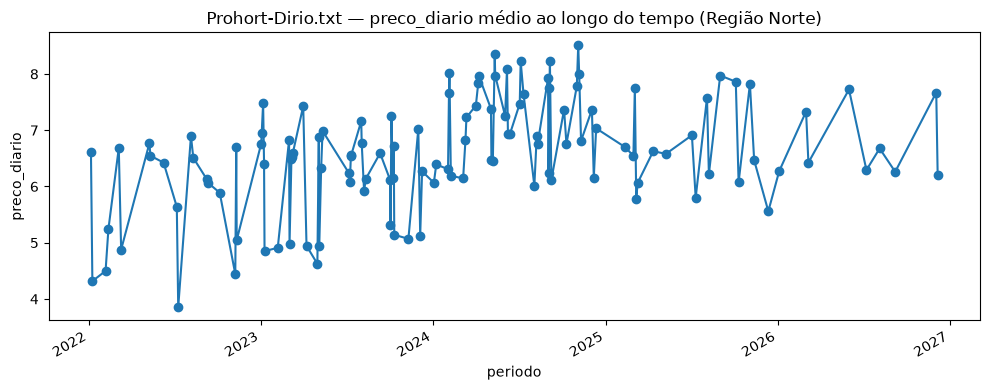

#### Evolução do valor ao longo do tempo, por UF do Ceasa (mercado)

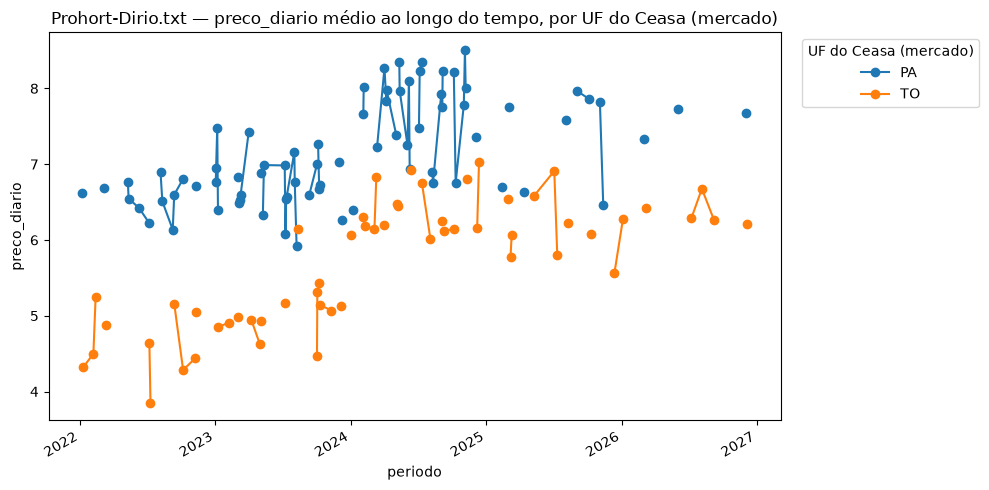

### Prohort-Mensal.txt — 19781 linhas (Região Norte)

#### Visão geral dos dados

Colunas (13): ['id_ano_comercializacao', 'id_mes_comercializacao', 'municipio_origem_produto', 'cod_ibge_municipio_origem_produto', 'uf_origem_produto', 'dsc_ceasa', 'uf_ceasa', 'municipio_ceasa', 'cod_ibge_municipio_ceasa', 'dsc_produto', 'qtd_comercializada_kg', 'valor_comercializado', 'pais_origem']


,id_ano_comercializacao,id_mes_comercializacao,municipio_origem_produto,cod_ibge_municipio_origem_produto,uf_origem_produto,dsc_ceasa,uf_ceasa,municipio_ceasa,cod_ibge_municipio_ceasa,dsc_produto,qtd_comercializada_kg,valor_comercializado,pais_origem
0,2021,8,SANTA RITA DO TOCANTINS-TO,1718899,TO,CEASA/GO - GOIANIA,GO,GOIÂNIA-GO,5208707,MELANCIA,64000,82133.33,Brasil
1,2021,8,PALMAS-TO,1721000,TO,CEASA/GO - GOIANIA,GO,GOIÂNIA-GO,5208707,MELANCIA,14000,17966.67,Brasil
2,2021,8,MIRANORTE-TO,1713304,TO,CEASA/GO - GOIANIA,GO,GOIÂNIA-GO,5208707,MELANCIA,245000,314416.67,Brasil
3,2021,8,MIRACEMA DO TOCANTINS-TO,1713205,TO,CEASA/GO - GOIANIA,GO,GOIÂNIA-GO,5208707,MELANCIA,115000,147583.33,Brasil
4,2021,8,CRISTALÂNDIA-TO,1706100,TO,CEASA/GO - GOIANIA,GO,GOIÂNIA-GO,5208707,MELANCIA,132000,169400.00,Brasil
5,2021,8,MIRANORTE-TO,1713304,TO,CEASA/GO - GOIANIA,GO,GOIÂNIA-GO,5208707,ABACAXI PEROLA,416000,855111.11,Brasil
6,2021,8,MIRACEMA DO TOCANTINS-TO,1713205,TO,CEASA/GO - GOIANIA,GO,GOIÂNIA-GO,5208707,ABACAXI PEROLA,170000,349444.44,Brasil
7,2021,8,FLORESTA DO ARAGUAIA-PA,1503044,PA,CEASA/GO - GOIANIA,GO,GOIÂNIA-GO,5208707,ABACAXI PEROLA,14000,28777.78,Brasil


  Este arquivo tem mais de uma coluna de UF (UF de origem do produto, UF do Ceasa (mercado)). Uma linha entra no recorte da Região Norte se QUALQUER uma delas for de um estado do Norte — por isso os gráficos abaixo são mostrados separadamente por coluna, e é esperado que apareçam estados de fora do Norte em uma delas quando foi a outra coluna que pertencia à região.


#### Distribuição por UF de origem do produto

,ocorrencias
uf_origem_produto,
AC,8297
TO,3422
PA,3361
SP,1762
RO,1348
AM,369
PR,327
MG,296
SC,228


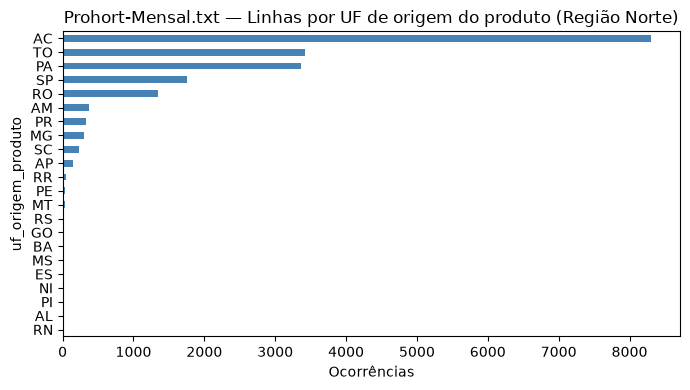

#### Distribuição por UF do Ceasa (mercado)

,ocorrencias
uf_ceasa,
AC,11509
SP,2456
RJ,1581
PE,1486
MG,801
PR,674
GO,590
DF,289
SC,145


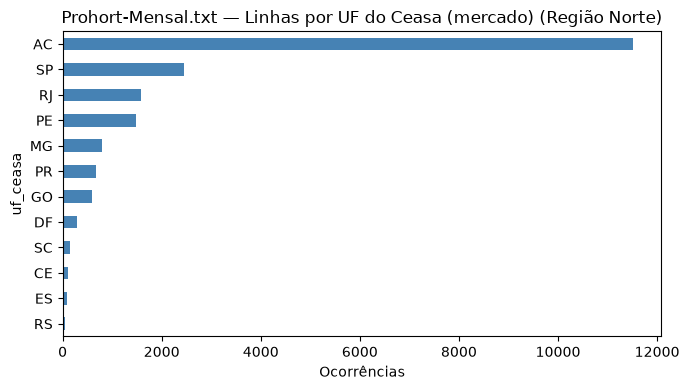

#### Produtos mais frequentes

,ocorrencias
dsc_produto,
ABACAXI PEROLA,1064
MELANCIA,904
OUTROS GENEROS,787
ABACAXI,783
BANANA COMPRIDA,671
BANANA PRATA,493
CEBOLINHA,431
LIMAO TAHITI,424
COUVE,414


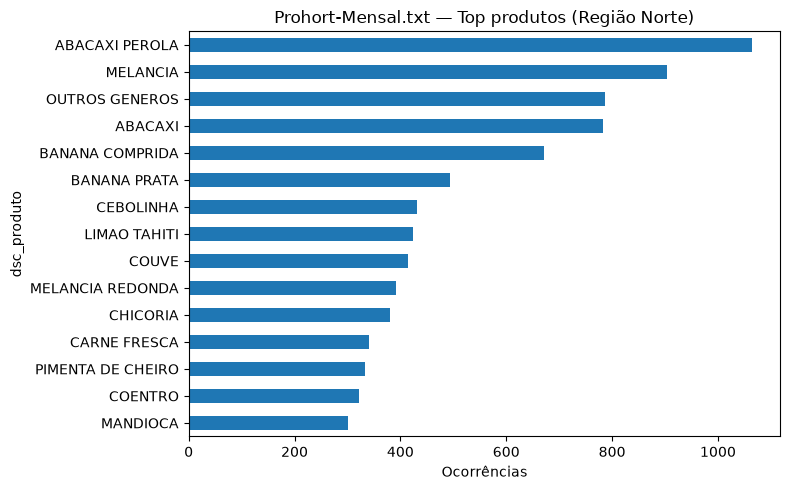

#### Municípios mais frequentes

,ocorrencias
RIO BRANCO-AC (AC),11509
SÃO PAULO-SP (SP),1597
RECIFE-PE (PE),1486
RIO DE JANEIRO-RJ (RJ),1428
CAMPINAS-SP (SP),859
GOIÂNIA-GO (GO),590
CONTAGEM-MG (MG),405
CURITIBA-PR (PR),392
BRASÍLIA-DF (DF),289
UBERLÂNDIA-MG (MG),281


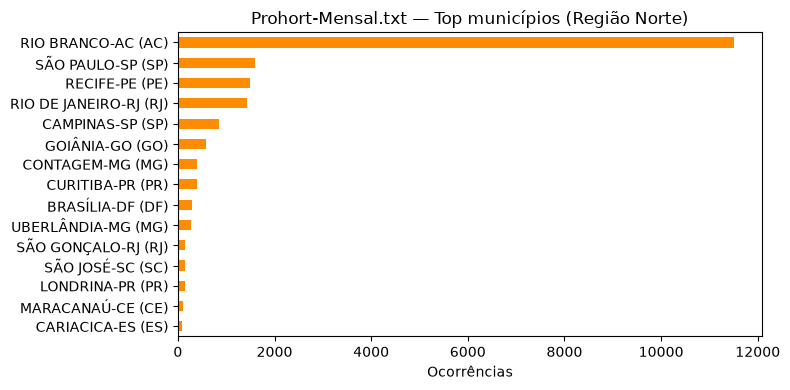

#### Evolução do valor ao longo do tempo (região)

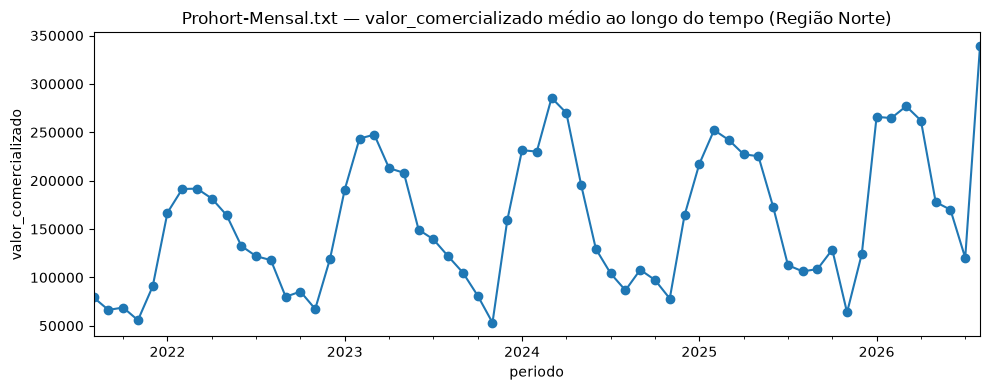

#### Evolução do valor ao longo do tempo, por UF de origem do produto

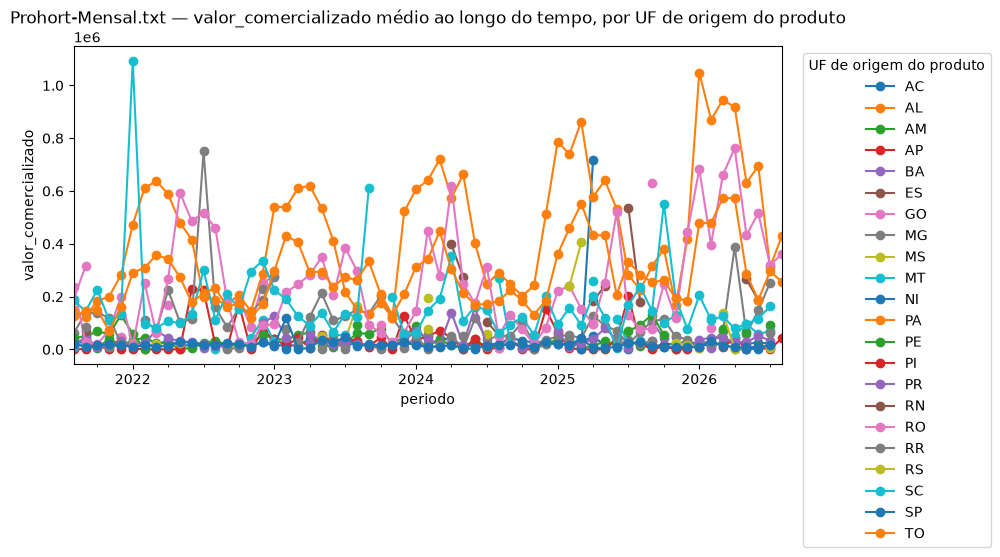

#### Evolução do valor ao longo do tempo, por UF do Ceasa (mercado)

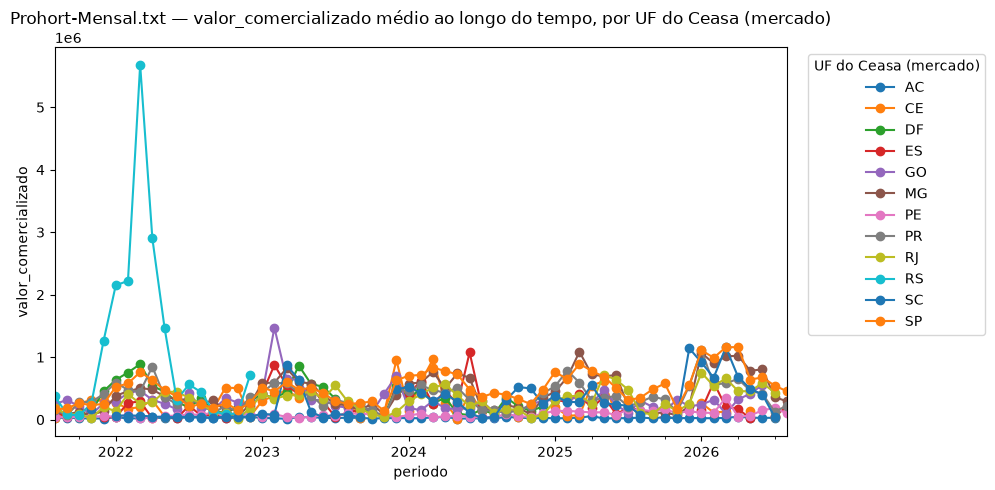

#### Quantidade comercializada ao longo do tempo

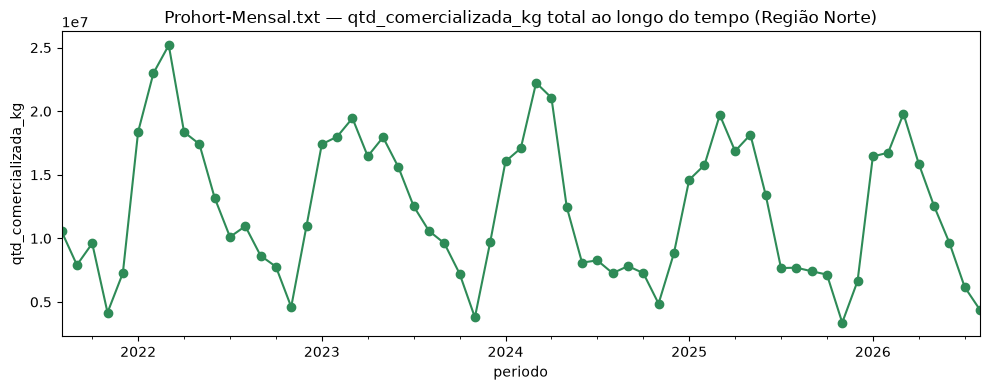

In [21]:
def obter_colunas_uf(df):
    candidatas = [c for c in df.columns if re.search(r"(?:^|_)uf(?:_|$)", c, re.IGNORECASE)]
    rotulos = {}
    for c in candidatas:
        if re.search(r"ceasa", c, re.IGNORECASE):
            rotulos[c] = "UF do Ceasa (mercado)"
        elif re.search(r"origem", c, re.IGNORECASE):
            rotulos[c] = "UF de origem do produto"
        else:
            rotulos[c] = "UF"
    return rotulos


def explorar_arquivo(nome, df_norte):
    if df_norte.empty:
        cabecalho(f"{nome} — sem dado da Região Norte, pulando.", nivel=3)
        return

    cabecalho(f"{nome} — {len(df_norte)} linhas (Região Norte)", nivel=3)

    col_produto = coluna_por_regex(df_norte, r"dsc_produto|^produto$|descricao_produto")
    col_valor = coluna_por_regex(df_norte, r"valor|preco", preferir_numerica=True)
    col_qtd = coluna_por_regex(
        df_norte, r"qtd_comercializada|quantidade_comercializada|^quantidade$",
        preferir_numerica=True,
    )
    col_ano = coluna_por_regex(df_norte, r"(?:^|_)ano(?:$|_)")
    col_mes = coluna_por_regex(df_norte, r"(?:^|_)mes(?:$|_)")
    col_data = coluna_por_regex(df_norte, r"data_preco|data_inicial|^data$")
    col_municipio = coluna_por_prioridade(
        df_norte, r"^municipio_ceasa$", r"^nom_municipio$", r"municipio_ceasa", r"municipio",
    )
    colunas_uf = obter_colunas_uf(df_norte)
    # Para rotular município, prioriza a UF "de comercialização"/Ceasa
    # sobre a "de origem do produto" (o município é o do Ceasa).
    col_uf_municipio = coluna_por_prioridade(
        df_norte, r"^uf_ceasa$", r"^uf$", r"uf_ceasa", r"uf",
    )

    # --- Visão geral dos dados -------------------------------------------
    cabecalho("Visão geral dos dados", nivel=4)
    print(f"Colunas ({len(df_norte.columns)}): {list(df_norte.columns)}")
    display(df_norte.head(8))

    # --- Distribuição por UF -------------------------------------------
    if len(colunas_uf) > 1:
        print(
            "  Este arquivo tem mais de uma coluna de UF "
            f"({', '.join(colunas_uf.values())}). Uma linha entra no "
            "recorte da Região Norte se QUALQUER uma delas for de um "
            "estado do Norte — por isso os gráficos abaixo são "
            "mostrados separadamente por coluna, e é esperado que "
            "apareçam estados de fora do Norte em uma delas quando foi "
            "a outra coluna que pertencia à região."
        )

    for col, rotulo in colunas_uf.items():
        cabecalho(f"Distribuição por {rotulo}", nivel=4)
        contagem_uf = df_norte[col].astype(str).str.strip().str.upper().value_counts()
        display(contagem_uf.to_frame("ocorrencias"))

        contagem_uf.sort_values().plot(
            kind="barh", figsize=(7, 4), color="steelblue",
            title=f"{nome} — Linhas por {rotulo} (Região Norte)"
        )
        plt.xlabel("Ocorrências")
        plt.tight_layout()
        plt.show()

    # --- Produtos mais frequentes ------------------------------------------
    if col_produto:
        cabecalho("Produtos mais frequentes", nivel=4)
        top_produtos = df_norte[col_produto].value_counts().head(15)
        display(top_produtos.to_frame("ocorrencias"))

        top_produtos.sort_values().plot(
            kind="barh", figsize=(8, 5),
            title=f"{nome} — Top produtos (Região Norte)"
        )
        plt.xlabel("Ocorrências")
        plt.tight_layout()
        plt.show()

    # --- Municípios mais frequentes (só quando há mais de um) --------------
    if col_municipio and df_norte[col_municipio].nunique(dropna=True) > 1:
        cabecalho("Municípios mais frequentes", nivel=4)
        if col_uf_municipio:
            rotulo = (
                df_norte[col_municipio].astype(str).str.strip()
                + " (" + df_norte[col_uf_municipio].astype(str).str.strip().str.upper() + ")"
            )
        else:
            rotulo = df_norte[col_municipio]
        top_municipios = rotulo.value_counts().head(15)
        display(top_municipios.to_frame("ocorrencias"))

        top_municipios.sort_values().plot(
            kind="barh", figsize=(8, 4), color="darkorange",
            title=f"{nome} — Top municípios (Região Norte)"
        )
        plt.xlabel("Ocorrências")
        plt.tight_layout()
        plt.show()

    # --- Série temporal: valor e/ou quantidade ------------------------------
    df_plot = df_norte.copy()
    df_plot["periodo"] = construir_periodo(df_plot, col_data, col_ano, col_mes)
    tem_periodo = df_plot["periodo"].notna().any()

    if not tem_periodo and (col_data or (col_ano and col_mes)):
        print("  (não foi possível montar uma linha do tempo com as colunas de data disponíveis)")

    if col_valor and tem_periodo:
        df_plot[col_valor] = garantir_numerico(df_plot[col_valor])
        if df_plot[col_valor].notna().any():
            cabecalho("Evolução do valor ao longo do tempo (região)", nivel=4)
            serie_valor = (
                df_plot.dropna(subset=["periodo", col_valor])
                .groupby("periodo")[col_valor]
                .mean()
                .sort_index()
            )
            serie_valor.plot(
                figsize=(10, 4), marker="o",
                title=f"{nome} — {col_valor} médio ao longo do tempo (Região Norte)"
            )
            plt.ylabel(col_valor)
            plt.tight_layout()
            plt.show()

            for col_uf, rotulo_uf in colunas_uf.items():
                if df_plot[col_uf].nunique(dropna=True) <= 1:
                    continue
                cabecalho(f"Evolução do valor ao longo do tempo, por {rotulo_uf}", nivel=4)
                serie_valor_uf = (
                    df_plot.dropna(subset=["periodo", col_valor])
                    .assign(**{col_uf: df_plot[col_uf].astype(str).str.strip().str.upper()})
                    .groupby(["periodo", col_uf])[col_valor]
                    .mean()
                    .unstack(col_uf)
                    .sort_index()
                )
                serie_valor_uf.plot(figsize=(10, 5), marker="o")
                plt.title(f"{nome} — {col_valor} médio ao longo do tempo, por {rotulo_uf}")
                plt.ylabel(col_valor)
                plt.legend(title=rotulo_uf, bbox_to_anchor=(1.02, 1), loc="upper left")
                plt.tight_layout()
                plt.show()

    if col_qtd and tem_periodo:
        df_plot[col_qtd] = garantir_numerico(df_plot[col_qtd])
        if df_plot[col_qtd].notna().any():
            cabecalho("Quantidade comercializada ao longo do tempo", nivel=4)
            serie_qtd = (
                df_plot.dropna(subset=["periodo", col_qtd])
                .groupby("periodo")[col_qtd]
                .sum()
                .sort_index()
            )
            serie_qtd.plot(
                figsize=(10, 4), marker="o", color="seagreen",
                title=f"{nome} — {col_qtd} total ao longo do tempo (Região Norte)"
            )
            plt.ylabel(col_qtd)
            plt.tight_layout()
            plt.show()

    print()


for r in resultados:
    explorar_arquivo(r["arquivo"], r["df_norte"])


# Fonte 6 (Complementar): ANP — Sistema de Levantamento de Preços de Combustíveis (SLP)

##Titulo especifico da tabela:

##Método de coleta: consulta/download de preços de gasolina e diesel por município

## Configuração


In [22]:
ANO_INICIO = 2020     # (mínimo disponível: 2004)
ANO_FIM = 2026

MUNICIPIO_ALVO = "MANAUS"
UF_ALVO = "AM"

TIMEOUT = 60
PAUSA_ENTRE_REQUISICOES = 1.0

BASE_SEMESTRAL = "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas"
BASE_ULTIMAS_4_SEMANAS = "https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/qus"

PASTA_SAIDA = TRATADOS  # saídas já limpas/filtradas/agregadas: saída tratada (padrão igual ao da ANTAQ)
PASTA_SAIDA.mkdir(parents=True, exist_ok=True)

HEADERS = {
    "User-Agent": "Mozilla/5.0 (compatible; pesquisa-academica/1.0; +coleta-dados-abertos-ANP)"
}

## Funções auxiliares

In [23]:
from requests.adapters import HTTPAdapter, Retry

def criar_sessao() -> requests.Session:
    sessao = requests.Session()
    retries = Retry(
        total=5,
        backoff_factor=2,          # 2s, 4s, 8s, 16s, 32s entre tentativas
        status_forcelist=[429, 500, 502, 503, 504],
        allowed_methods=["GET"],
    )
    adaptador = HTTPAdapter(max_retries=retries)
    sessao.mount("https://", adaptador)
    sessao.mount("http://", adaptador)
    return sessao


SESSAO = criar_sessao()


def baixar_bytes(url: str, tentativas: int = 4) -> bytes:
    ultimo_erro = None
    for tentativa in range(1, tentativas + 1):
        try:
            with SESSAO.get(url, headers=HEADERS, timeout=TIMEOUT, stream=True) as resp:
                resp.raise_for_status()
                tamanho_esperado = resp.headers.get("Content-Length")
                tamanho_esperado = int(tamanho_esperado) if tamanho_esperado else None

                pedacos = []
                for pedaco in resp.iter_content(chunk_size=1024 * 256):
                    if pedaco:
                        pedacos.append(pedaco)
                conteudo = b"".join(pedacos)

                if tamanho_esperado is not None and len(conteudo) != tamanho_esperado:
                    raise IOError(
                        f"Download incompleto: recebidos {len(conteudo)} bytes, "
                        f"esperados {tamanho_esperado} bytes."
                    )
                return conteudo
        except (requests.exceptions.ChunkedEncodingError,
                requests.exceptions.ConnectionError,
                IOError) as e:
            ultimo_erro = e
            espera = 2 * tentativa
            print(f"  ↳ tentativa {tentativa}/{tentativas} falhou ({e}); nova tentativa em {espera}s...")
            time.sleep(espera)
    raise ConnectionError(f"Falha ao baixar {url} após {tentativas} tentativas: {ultimo_erro}")


def ler_csv_anp(conteudo: bytes) -> pd.DataFrame:
    ultimo_erro = None
    for enc in ("latin1", "cp1252", "utf-8"):
        try:
            return pd.read_csv(
                io.BytesIO(conteudo),
                sep=";",
                encoding=enc,
                dtype=str,
                engine="python",
                on_bad_lines="skip",
            )
        except Exception as e:
            ultimo_erro = e
            continue
    raise ValueError(f"Não foi possível ler o CSV com as codificações testadas: {ultimo_erro}")


def normalizar_colunas(df: pd.DataFrame) -> pd.DataFrame:
    import unicodedata

    def limpar(col):
        col = col.strip().upper()
        col = "".join(
            c for c in unicodedata.normalize("NFKD", col) if not unicodedata.combining(c)
        )
        col = col.replace(" - ", "_").replace(" ", "_")
        return col

    df = df.copy()
    df.columns = [limpar(c) for c in df.columns]
    return df


def extrair_csvs_de_zip(conteudo_zip: bytes) -> pd.DataFrame:
    dfs = []
    with zipfile.ZipFile(io.BytesIO(conteudo_zip)) as z:
        nomes_csv = [n for n in z.namelist() if n.lower().endswith(".csv")]
        if not nomes_csv:
            raise ValueError("Nenhum arquivo .csv encontrado dentro do .zip.")
        for nome in nomes_csv:
            with z.open(nome) as f:
                dfs.append(ler_csv_anp(f.read()))
    return pd.concat(dfs, ignore_index=True)


## Coleta da série semestral — Combustíveis Automotivos (gasolina, etanol, diesel, GNV

In [24]:

NOMES_ESPECIAIS_CA = {
    (2022, 1): "precos-semestrais-ca.zip",
}


def url_arquivo_ca(ano: int, semestre: int) -> str:
    nome = NOMES_ESPECIAIS_CA.get((ano, semestre), f"ca-{ano}-{semestre:02d}")
    extensao = "zip" if (ano, semestre) >= (2022, 1) else "csv"
    if (ano, semestre) in NOMES_ESPECIAIS_CA:
        return f"{BASE_SEMESTRAL}/ca/{nome}"
    return f"{BASE_SEMESTRAL}/ca/{nome}.{extensao}"


def baixar_semestre_ca(ano: int, semestre: int) -> pd.DataFrame:
    url = url_arquivo_ca(ano, semestre)
    conteudo = baixar_bytes(url)
    if url.lower().endswith(".zip"):
        df = extrair_csvs_de_zip(conteudo)
    else:
        df = ler_csv_anp(conteudo)
    df = normalizar_colunas(df)
    df["ANO_REFERENCIA"] = ano
    df["SEMESTRE_REFERENCIA"] = semestre
    df["CATEGORIA_ANP"] = "combustiveis_automotivos"
    return df


registros_ca = []
falhas_ca = []

for ano in range(ANO_INICIO, ANO_FIM + 1):
    for semestre in (1, 2):
        try:
            df_sem = baixar_semestre_ca(ano, semestre)
            registros_ca.append(df_sem)
            print(f"[CA] {ano}-S{semestre}: {len(df_sem):,} linhas".replace(",", "."))
        except requests.HTTPError as e:
            # semestre ainda não publicado (ex.: futuro) — não é um erro grave
            print(f"[CA] {ano}-S{semestre}: indisponível ({e.response.status_code})")
            falhas_ca.append((ano, semestre, str(e)))
        except Exception as e:
            print(f"[CA] {ano}-S{semestre}: ERRO — {e}")
            falhas_ca.append((ano, semestre, str(e)))
        time.sleep(PAUSA_ENTRE_REQUISICOES)

df_ca = pd.concat(registros_ca, ignore_index=True) if registros_ca else pd.DataFrame()
print(f"\nTotal de linhas (combustíveis automotivos, todos os municípios): {len(df_ca):,}".replace(",", "."))

[CA] 2020-S1: 496.663 linhas
[CA] 2020-S2: 222.637 linhas
[CA] 2021-S1: 334.681 linhas
[CA] 2021-S2: 472.856 linhas
[CA] 2022-S1: 529.424 linhas
[CA] 2022-S2: 378.078 linhas
[CA] 2023-S1: 431.576 linhas
[CA] 2023-S2: 472.424 linhas
[CA] 2024-S1: 477.154 linhas
[CA] 2024-S2: 421.382 linhas
[CA] 2025-S1: 429.523 linhas
[CA] 2025-S2: 384.208 linhas
[CA] 2026-S1: 422.418 linhas
  ↳ tentativa 1/4 falhou (404 Client Error: Not Found for url: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2026-02.zip); nova tentativa em 2s...
  ↳ tentativa 2/4 falhou (404 Client Error: Not Found for url: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2026-02.zip); nova tentativa em 4s...
  ↳ tentativa 3/4 falhou (404 Client Error: Not Found for url: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/ca/ca-2026-02.zip); nova tentativa em 6s...
  ↳ tentativa 4/4 falhou (404 Client Error: Not Found

## Coleta da série semestral — GLP P13 (gás de cozinha)

In [25]:
# Garante as configurações mínimas mesmo se esta célula for executada
# isoladamente (ex.: após reinício do runtime, quando os globais somem)
try:
    ANO_INICIO, ANO_FIM
except NameError:
    ANO_INICIO = 2020
    ANO_FIM = 2026

NOMES_ESPECIAIS_GLP = {
    (2022, 1): "precos-semestrais-glp-2022-01.csv",
    (2021, 1): "precos-semestrais-glp2021-01.csv",
}


def url_arquivo_glp(ano: int, semestre: int) -> str:
    nome = NOMES_ESPECIAIS_GLP.get((ano, semestre), f"glp-{ano}-{semestre:02d}.csv")
    return f"{BASE_SEMESTRAL}/glp/{nome}"


def baixar_semestre_glp(ano: int, semestre: int) -> pd.DataFrame:
    url = url_arquivo_glp(ano, semestre)
    conteudo = baixar_bytes(url)
    df = ler_csv_anp(conteudo)
    df = normalizar_colunas(df)
    df["ANO_REFERENCIA"] = ano
    df["SEMESTRE_REFERENCIA"] = semestre
    df["CATEGORIA_ANP"] = "glp_p13"
    return df


registros_glp = []
falhas_glp = []

for ano in range(ANO_INICIO, ANO_FIM + 1):
    for semestre in (1, 2):
        try:
            df_sem = baixar_semestre_glp(ano, semestre)
            registros_glp.append(df_sem)
            print(f"[GLP] {ano}-S{semestre}: {len(df_sem):,} linhas".replace(",", "."))
        except requests.HTTPError as e:
            print(f"[GLP] {ano}-S{semestre}: indisponível ({e.response.status_code})")
            falhas_glp.append((ano, semestre, str(e)))
        except Exception as e:
            print(f"[GLP] {ano}-S{semestre}: ERRO — {e}")
            falhas_glp.append((ano, semestre, str(e)))
        time.sleep(PAUSA_ENTRE_REQUISICOES)

df_glp = pd.concat(registros_glp, ignore_index=True) if registros_glp else pd.DataFrame()
print(f"\nTotal de linhas (GLP P13, todos os municípios): {len(df_glp):,}".replace(",", "."))

[GLP] 2020-S1: 114.241 linhas
[GLP] 2020-S2: 45.412 linhas
[GLP] 2021-S1: 60.280 linhas
[GLP] 2021-S2: 89.372 linhas
[GLP] 2022-S1: 100.133 linhas
[GLP] 2022-S2: 67.371 linhas
[GLP] 2023-S1: 105.341 linhas
[GLP] 2023-S2: 121.725 linhas
[GLP] 2024-S1: 122.071 linhas
[GLP] 2024-S2: 38.425 linhas
[GLP] 2025-S1: 71.780 linhas
[GLP] 2025-S2: 53.423 linhas
[GLP] 2026-S1: 80.187 linhas
  ↳ tentativa 1/4 falhou (404 Client Error: Not Found for url: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/glp/glp-2026-02.csv); nova tentativa em 2s...
  ↳ tentativa 2/4 falhou (404 Client Error: Not Found for url: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/glp/glp-2026-02.csv); nova tentativa em 4s...
  ↳ tentativa 3/4 falhou (404 Client Error: Not Found for url: https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/arquivos/shpc/dsas/glp/glp-2026-02.csv); nova tentativa em 6s...
  ↳ tentativa 4/4 falhou (404 Client Error

## Snapshot mais recente — últimas 4 semanas

In [26]:
ARQUIVOS_ULTIMAS_4_SEMANAS = {
    "combustiveis_automotivos_gasolina_etanol": "ultimas-4-semanas-gasolina-etanol.csv",
    "combustiveis_automotivos_diesel_gnv": "ultimas-4-semanas-diesel-gnv.csv",
    "glp_p13": "ultimas-4-semanas-glp.csv",
}

registros_recentes = []

for categoria, arquivo in ARQUIVOS_ULTIMAS_4_SEMANAS.items():
    url = f"{BASE_ULTIMAS_4_SEMANAS}/{arquivo}"
    try:
        conteudo = baixar_bytes(url)
        df_rec = ler_csv_anp(conteudo)
        df_rec = normalizar_colunas(df_rec)
        df_rec["CATEGORIA_ANP"] = categoria
        registros_recentes.append(df_rec)
        print(f"[Últimas 4 semanas] {categoria}: {len(df_rec):,} linhas".replace(",", "."))
    except Exception as e:
        print(f"[Últimas 4 semanas] {categoria}: ERRO — {e}")
    time.sleep(PAUSA_ENTRE_REQUISICOES)

df_recente = (
    pd.concat(registros_recentes, ignore_index=True) if registros_recentes else pd.DataFrame()
)

[Últimas 4 semanas] combustiveis_automotivos_gasolina_etanol: 46.197 linhas
[Últimas 4 semanas] combustiveis_automotivos_diesel_gnv: 21.364 linhas
[Últimas 4 semanas] glp_p13: 12.869 linhas


## Padronização, limpeza e filtro para a Região Norte

In [27]:
def limpar_precos(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    col_data = next((c for c in df.columns if "DATA" in c and "COLETA" in c), None)
    col_venda = next((c for c in df.columns if "VALOR_DE_VENDA" in c or "VALOR_VENDA" in c), None)
    col_compra = next((c for c in df.columns if "VALOR_DE_COMPRA" in c or "VALOR_COMPRA" in c), None)

    if col_data:
        df[col_data] = pd.to_datetime(df[col_data], dayfirst=True, errors="coerce")
        df = df.rename(columns={col_data: "DATA_COLETA"})

    for col_original, novo_nome in ((col_venda, "VALOR_VENDA"), (col_compra, "VALOR_COMPRA")):
        if col_original:
            df[col_original] = (
                df[col_original]
                .astype(str)
                .str.replace(".", "", regex=False)
                .str.replace(",", ".", regex=False)
            )
            df[col_original] = pd.to_numeric(df[col_original], errors="coerce")
            df = df.rename(columns={col_original: novo_nome})

    return df


def filtrar_municipio(df: pd.DataFrame, municipio: str, uf: str | None = None) -> pd.DataFrame:
    col_municipio = next((c for c in df.columns if "MUNICIPIO" in c), None)
    if col_municipio is None:
        raise KeyError("Coluna de município não encontrada no DataFrame.")

    mask = df[col_municipio].astype(str).str.upper().str.strip() == municipio.upper()

    if uf:
        col_uf = next((c for c in df.columns if c in ("ESTADO_SIGLA", "ESTADO", "UF")), None)
        if col_uf:
            mask &= df[col_uf].astype(str).str.upper().str.strip() == uf.upper()

    return df.loc[mask].copy()


UFS_REGIAO_NORTE = ["AC", "AM", "AP", "PA", "RO", "RR", "TO"]


def filtrar_ufs(df: pd.DataFrame, ufs: list[str]) -> pd.DataFrame:
    """Filtra o DataFrame por uma lista de siglas de UF (ex.: Região Norte)."""
    col_uf = next((c for c in df.columns if c in ("ESTADO_SIGLA", "ESTADO", "UF")), None)
    if col_uf is None:
        raise KeyError("Coluna de UF/Estado não encontrada no DataFrame.")

    ufs_upper = [u.upper().strip() for u in ufs]
    mask = df[col_uf].astype(str).str.upper().str.strip().isin(ufs_upper)
    return df.loc[mask].copy()


partes = [d for d in (df_ca, df_glp, df_recente) if not d.empty]
df_bruto = pd.concat(partes, ignore_index=True, sort=False) if partes else pd.DataFrame()

df_limpo = limpar_precos(df_bruto)

df_norte = filtrar_ufs(df_limpo, UFS_REGIAO_NORTE)

df_manaus = filtrar_municipio(df_limpo, MUNICIPIO_ALVO, UF_ALVO)

print(f"Total de registros coletados (Brasil, todas as categorias): {len(df_limpo):,}".replace(",", "."))
print(f"Total de registros na Região Norte: {len(df_norte):,}".replace(",", "."))
print(f"Total de registros em Manaus/AM: {len(df_manaus):,}".replace(",", "."))

df_norte[["DATA_COLETA", "MUNICIPIO", "PRODUTO", "VALOR_VENDA", "BANDEIRA", "CATEGORIA_ANP"]].head(10)

Total de registros coletados (Brasil. todas as categorias): 6.623.215
Total de registros na Região Norte: 466.666
Total de registros em Manaus/AM: 69.640


,DATA_COLETA,MUNICIPIO,PRODUTO,VALOR_VENDA,BANDEIRA,CATEGORIA_ANP
11,2020-01-03,CRUZEIRO DO SUL,GASOLINA,5.20,PETROBRAS DISTRIBUIDORA S.A.,combustiveis_automotivos
12,2020-01-03,CRUZEIRO DO SUL,DIESEL,4.85,PETROBRAS DISTRIBUIDORA S.A.,combustiveis_automotivos
13,2020-01-03,CRUZEIRO DO SUL,DIESEL S10,4.95,PETROBRAS DISTRIBUIDORA S.A.,combustiveis_automotivos
14,2020-01-03,CRUZEIRO DO SUL,GASOLINA,5.20,PETROBRAS DISTRIBUIDORA S.A.,combustiveis_automotivos
15,2020-01-03,CRUZEIRO DO SUL,DIESEL,4.85,PETROBRAS DISTRIBUIDORA S.A.,combustiveis_automotivos
16,2020-01-03,CRUZEIRO DO SUL,DIESEL S10,4.95,PETROBRAS DISTRIBUIDORA S.A.,combustiveis_automotivos
17,2020-01-03,CRUZEIRO DO SUL,GASOLINA,5.20,BRANCA,combustiveis_automotivos
18,2020-01-03,CRUZEIRO DO SUL,DIESEL,4.85,BRANCA,combustiveis_automotivos
19,2020-01-03,CRUZEIRO DO SUL,DIESEL S10,4.95,BRANCA,combustiveis_automotivos
20,2020-01-03,CRUZEIRO DO SUL,GASOLINA,4.98,PETROBRAS DISTRIBUIDORA S.A.,combustiveis_automotivos


## Série agregada semanal por produto

In [28]:
df_norte_validos = df_norte.dropna(subset=["DATA_COLETA", "VALOR_VENDA"]).copy()

col_uf = next((c for c in df_norte_validos.columns if c in ("ESTADO_SIGLA", "ESTADO", "UF")), None)

serie_semanal_norte_municipio = (
    df_norte_validos
    .assign(SEMANA=lambda d: d["DATA_COLETA"].dt.to_period("W").apply(lambda p: p.start_time))
    .groupby(["SEMANA", col_uf, "MUNICIPIO", "PRODUTO"], as_index=False)
    .agg(
        preco_medio=("VALOR_VENDA", "mean"),
        preco_min=("VALOR_VENDA", "min"),
        preco_max=("VALOR_VENDA", "max"),
        n_postos=("VALOR_VENDA", "count"),
    )
    .sort_values([col_uf, "MUNICIPIO", "PRODUTO", "SEMANA"])
    .reset_index(drop=True)
)

serie_semanal_norte_municipio.head(10)

,SEMANA,ESTADO_SIGLA,MUNICIPIO,PRODUTO,preco_medio,preco_min,preco_max,n_postos
0,2019-12-30,AC,CRUZEIRO DO SUL,DIESEL,4.85000,4.85,4.85,9
1,2020-01-06,AC,CRUZEIRO DO SUL,DIESEL,4.92000,4.85,4.94,9
2,2020-01-13,AC,CRUZEIRO DO SUL,DIESEL,4.94000,4.94,4.94,9
3,2020-01-20,AC,CRUZEIRO DO SUL,DIESEL,4.94000,4.94,4.94,9
4,2020-01-27,AC,CRUZEIRO DO SUL,DIESEL,4.94000,4.94,4.94,9
5,2020-02-03,AC,CRUZEIRO DO SUL,DIESEL,4.94000,4.94,4.94,8
6,2020-02-10,AC,CRUZEIRO DO SUL,DIESEL,4.88000,4.85,4.94,9
7,2020-02-17,AC,CRUZEIRO DO SUL,DIESEL,4.88375,4.85,4.94,8
8,2020-02-24,AC,CRUZEIRO DO SUL,DIESEL,4.88000,4.85,4.94,9
9,2020-03-02,AC,CRUZEIRO DO SUL,DIESEL,4.88000,4.85,4.94,9


## Salvando os resultados

In [29]:
serie_semanal_norte_regional = (
    df_norte_validos
    .assign(SEMANA=lambda d: d["DATA_COLETA"].dt.to_period("W").apply(lambda p: p.start_time))
    .groupby(["SEMANA", "PRODUTO"], as_index=False)
    .agg(
        preco_medio=("VALOR_VENDA", "mean"),
        preco_min=("VALOR_VENDA", "min"),
        preco_max=("VALOR_VENDA", "max"),
        n_postos=("VALOR_VENDA", "count"),
        n_municipios=("MUNICIPIO", "nunique"),
    )
    .sort_values(["PRODUTO", "SEMANA"])
    .reset_index(drop=True)
)

CAMINHO_NORTE = os.path.join(PASTA_SAIDA, "anp_slp_precos_norte.csv")
df_norte.to_csv(CAMINHO_NORTE, index=False)
registrar_proveniencia(
    os.path.basename(CAMINHO_NORTE),
    f"{BASE_SEMESTRAL} e {BASE_ULTIMAS_4_SEMANAS}",
    "ANP/SLP - preços de combustíveis, recorte Região Norte",
)

CAMINHO_MANAUS = os.path.join(PASTA_SAIDA, "anp_slp_precos_manaus.csv")
df_manaus.to_csv(CAMINHO_MANAUS, index=False)
registrar_proveniencia(
    os.path.basename(CAMINHO_MANAUS),
    f"{BASE_SEMESTRAL} e {BASE_ULTIMAS_4_SEMANAS}",
    "ANP/SLP - preços de combustíveis, recorte Manaus/AM",
)

CAMINHO_SEMANAL_MUNICIPIO = os.path.join(PASTA_SAIDA, "anp_slp_serie_semanal_municipio.csv")
serie_semanal_norte_municipio.to_csv(CAMINHO_SEMANAL_MUNICIPIO, index=False)
registrar_proveniencia(
    os.path.basename(CAMINHO_SEMANAL_MUNICIPIO),
    f"{BASE_SEMESTRAL} e {BASE_ULTIMAS_4_SEMANAS}",
    "ANP/SLP - série semanal de preços por município (Região Norte)",
)

CAMINHO_SEMANAL_REGIONAL = os.path.join(PASTA_SAIDA, "anp_slp_serie_semanal_regional.csv")
serie_semanal_norte_regional.to_csv(CAMINHO_SEMANAL_REGIONAL, index=False)
registrar_proveniencia(
    os.path.basename(CAMINHO_SEMANAL_REGIONAL),
    f"{BASE_SEMESTRAL} e {BASE_ULTIMAS_4_SEMANAS}",
    "ANP/SLP - série semanal de preços regional (Região Norte)",
)

print("Arquivos salvos em", PASTA_SAIDA.resolve())
serie_semanal_norte_regional.head(10)

Proveniência registrada: anp_slp_precos_norte.csv
Proveniência registrada: anp_slp_precos_manaus.csv
Proveniência registrada: anp_slp_serie_semanal_municipio.csv
Proveniência registrada: anp_slp_serie_semanal_regional.csv
Arquivos salvos em C:\Users\Luiggy\TP1 - CD\Dados_precos\Dados Tratados


,SEMANA,PRODUTO,preco_medio,preco_min,preco_max,n_postos,n_municipios
0,2019-12-30,DIESEL,4.141331,3.620,4.99,163,23
1,2020-01-06,DIESEL,4.098525,3.620,4.99,257,33
2,2020-01-13,DIESEL,4.088249,3.579,4.99,265,33
3,2020-01-20,DIESEL,4.122437,3.590,4.99,247,33
4,2020-01-27,DIESEL,4.067298,3.489,4.95,265,34
5,2020-02-03,DIESEL,4.069703,3.479,4.99,249,34
6,2020-02-10,DIESEL,4.034945,3.419,4.99,256,35
7,2020-02-17,DIESEL,4.017554,3.419,4.95,271,34
8,2020-02-24,DIESEL,4.001954,3.329,4.95,259,34
9,2020-03-02,DIESEL,3.968223,3.329,4.95,264,34


## Gráficos

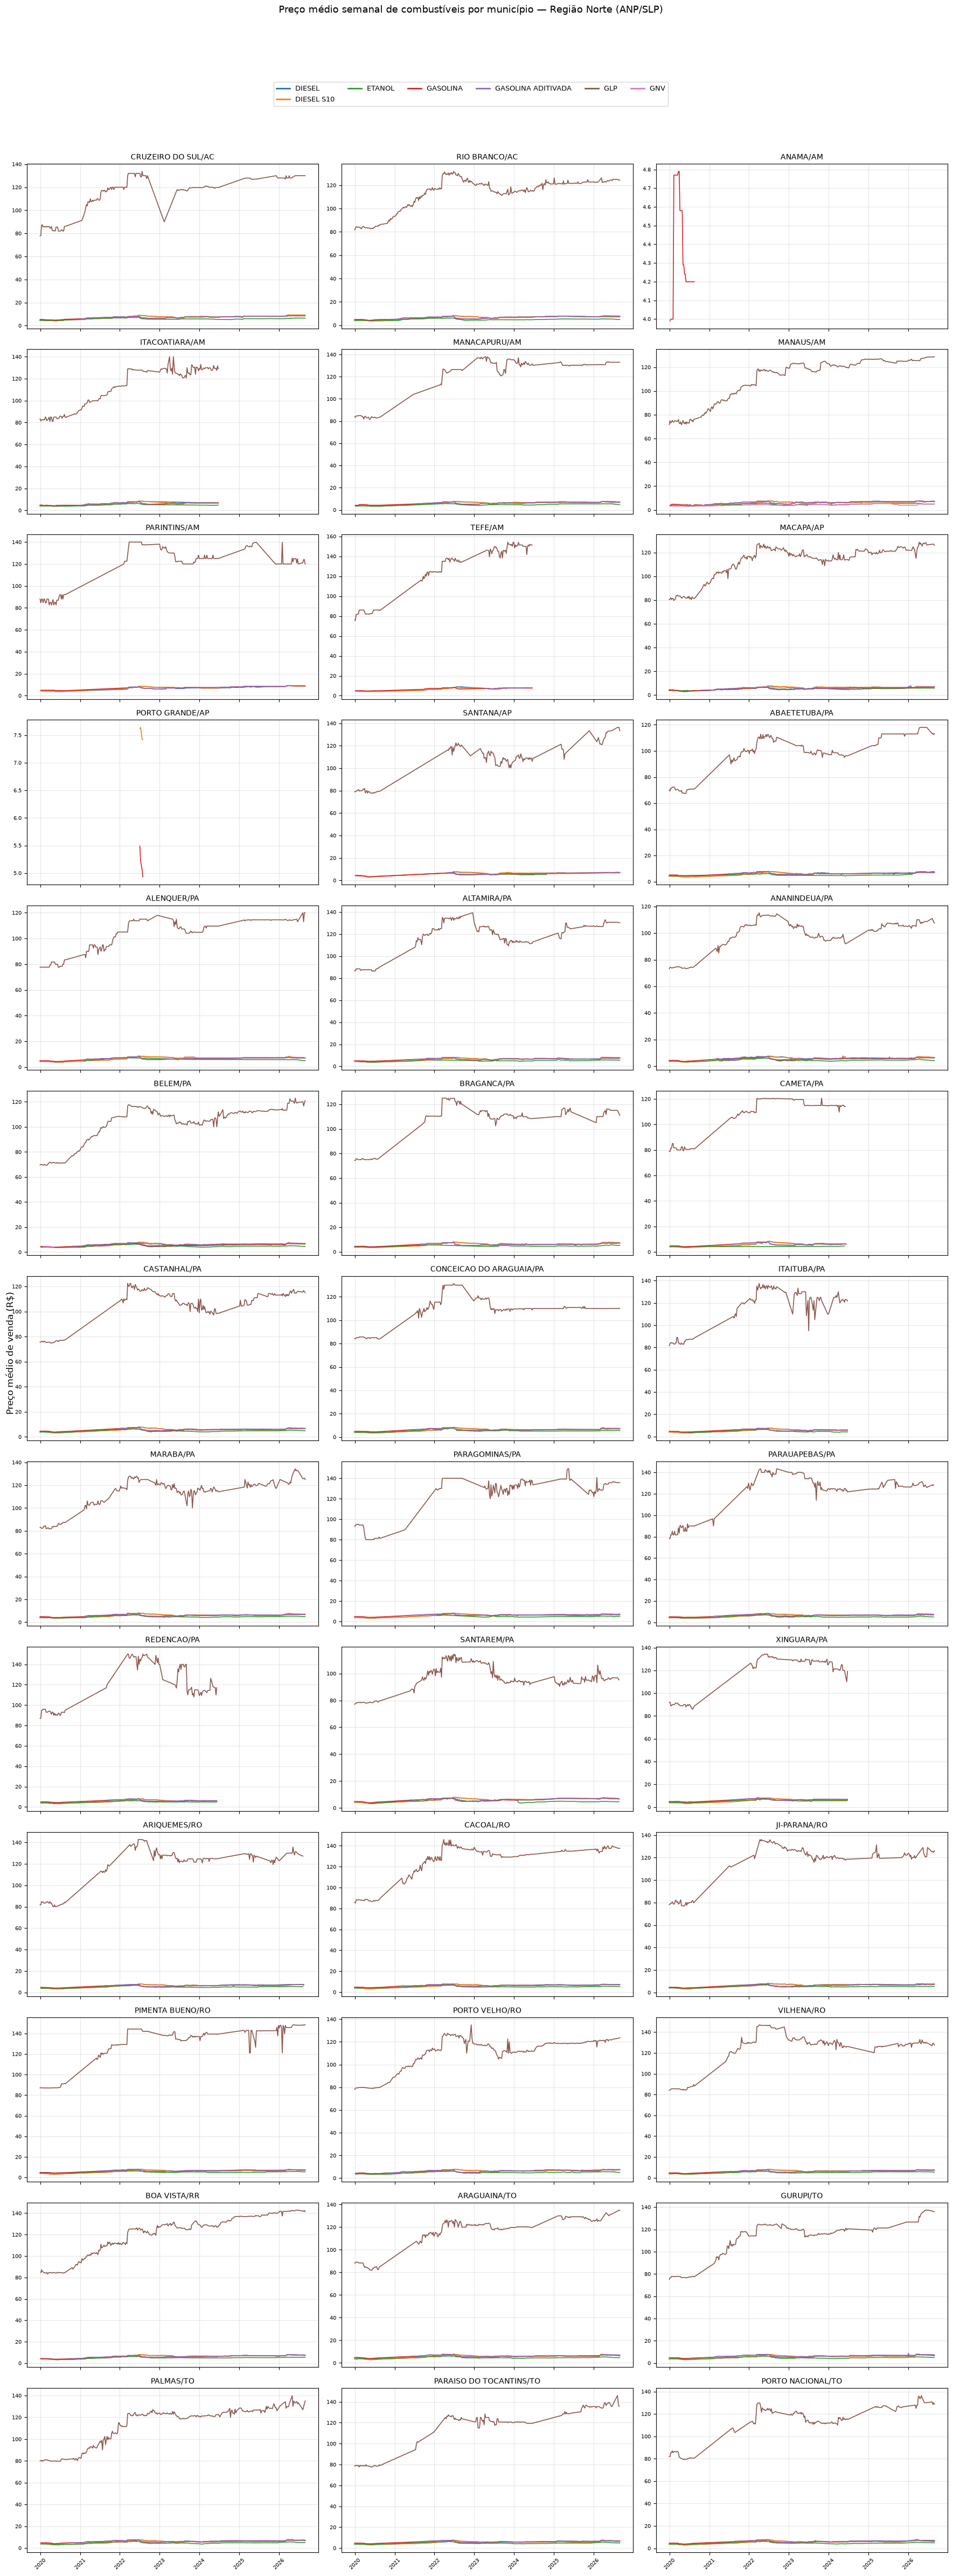

In [30]:
import math
import matplotlib.pyplot as plt

col_uf = next((c for c in serie_semanal_norte_municipio.columns if c in ("ESTADO_SIGLA", "ESTADO", "UF")), None)

municipios = (
    serie_semanal_norte_municipio[[col_uf, "MUNICIPIO"]]
    .drop_duplicates()
    .sort_values([col_uf, "MUNICIPIO"])
    .to_records(index=False)
)

n_municipios = len(municipios)
n_cols = 3
n_rows = math.ceil(n_municipios / n_cols)

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(6 * n_cols, 3.5 * n_rows),
    sharex=True,
    squeeze=False,
)

produtos = sorted(serie_semanal_norte_municipio["PRODUTO"].dropna().unique())
cores = plt.cm.tab10.colors
mapa_cores = {produto: cores[i % len(cores)] for i, produto in enumerate(produtos)}

for idx, (uf, municipio) in enumerate(municipios):
    linha, coluna = divmod(idx, n_cols)
    ax = axes[linha][coluna]

    dados_municipio = serie_semanal_norte_municipio[
        (serie_semanal_norte_municipio[col_uf] == uf)
        & (serie_semanal_norte_municipio["MUNICIPIO"] == municipio)
    ]

    for produto, grupo in dados_municipio.groupby("PRODUTO"):
        ax.plot(
            grupo["SEMANA"], grupo["preco_medio"],
            label=produto, linewidth=1.2, color=mapa_cores[produto],
        )

    ax.set_title(f"{municipio}/{uf}", fontsize=10)
    ax.grid(alpha=0.3)
    ax.tick_params(axis="x", labelrotation=45, labelsize=7)
    ax.tick_params(axis="y", labelsize=7)


for idx in range(n_municipios, n_rows * n_cols):
    linha, coluna = divmod(idx, n_cols)
    fig.delaxes(axes[linha][coluna])

handles = [plt.Line2D([0], [0], color=mapa_cores[p], lw=2, label=p) for p in produtos]
fig.legend(handles=handles, loc="upper center", ncol=min(len(produtos), 6),
           bbox_to_anchor=(0.5, 1.02), fontsize=9)

fig.suptitle("Preço médio semanal de combustíveis por município — Região Norte (ANP/SLP)",
             fontsize=13, y=1.05)
fig.supylabel("Preço médio de venda (R$)")
fig.tight_layout()
plt.show()